<a href="https://colab.research.google.com/github/Miguithub/Wavelets/blob/FV2/Wavelets_FV2_BTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# LIBRERIAS 1

In [ ]:
!pip install statsmodels

In [ ]:
import requests
import pandas as pd
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# DE

In [ ]:
btc = pd.read_parquet('/content/drive/MyDrive/mf12024.parquet')

In [ ]:
# eth = pd.read_parquet('/content/drive/MyDrive/1meth.parquet')

In [ ]:
# sol = pd.read_parquet('/content/drive/MyDrive/1msol.parquet')

Check

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   open_time               int64  
 1   open                    float64
 2   high                    float64
 3   low                     float64
 4   close                   float64
 5   volume                  float64
 6   close_time              int64  
 7   quote_volume            float64
 8   trade_count             int64  
 9   taker_buy_base_volume   float64
 10  taker_buy_quote_volume  float64
 11  ignore                  int64  
dtypes: float64(8), int64(4)
memory usage: 2.8 GB


In [ ]:
btc.tail()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
31622395,1735689595000,93576.00,93576.01,93576.00,93576.01,0.00083,1735689595999,77.668087,2,0.00067,62.695927,0
31622396,1735689596000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689596999,0.000000,0,0.00000,0.000000,0
31622397,1735689597000,93576.01,93576.01,93576.01,93576.01,0.00000,1735689597999,0.000000,0,0.00000,0.000000,0
31622398,1735689598000,93576.01,93576.01,93576.01,93576.01,0.00094,1735689598999,87.961449,3,0.00094,87.961449,0
31622399,1735689599000,93576.00,93576.00,93576.00,93576.00,0.00217,1735689599999,203.059920,3,0.00000,0.000000,0


In [ ]:
btc.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,1704067200000,42283.58,42283.59,42283.58,42283.58,0.07625,1704067200999,3224.123141,21,0.01658,701.061922,0
1,1704067201000,42283.59,42283.59,42283.58,42283.58,1.37528,1704067201999,58151.769471,51,0.75683,32001.489420,0
2,1704067202000,42283.58,42283.59,42283.58,42283.58,0.18867,1704067202999,7977.643051,9,0.00124,52.431652,0
3,1704067203000,42283.58,42283.59,42283.58,42283.59,0.83488,1704067203999,35301.720464,39,0.51935,21959.982467,0
4,1704067204000,42283.58,42283.59,42283.58,42283.59,0.23809,1704067204999,10067.297927,17,0.03653,1544.619543,0


Cleaness

In [ ]:
import pandas as pd

# Usá el nombre real de tu columna temporal
t = pd.to_datetime(btc["close_time"])

# diferencias entre timestamps en segundos
d = t.diff().dt.total_seconds()

# chequeo de equidistancia
es_equidistante = d.iloc[1:].nunique() == 1

print("Equidistante:", es_equidistante)
print("Intervalo único (segundos):", d.iloc[1] if es_equidistante else "No uniforme")

Equidistante: True
Intervalo único (segundos): 1e-06


In [ ]:
del t, d
import gc
gc.collect()

17

In [ ]:
btc.drop(columns=btc.columns[0], inplace=True)
btc["time"] = pd.to_datetime(btc["close_time"] // 1000, unit="s")
cols = ["time"] + [c for c in btc.columns if c not in ["time", "close_time"]]
btc = btc[cols]

In [ ]:
btc["day"] = btc["time"].dt.weekday + 1
btc.loc[btc["day"] == 7, "day"] = 0

In [ ]:
btc.tail()

,time,open,high,low,close,volume,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume,ignore,day
31622395,2024-12-31 23:59:55,93576.00,93576.01,93576.00,93576.01,0.00083,77.668087,2,0.00067,62.695927,0,2
31622396,2024-12-31 23:59:56,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622397,2024-12-31 23:59:57,93576.01,93576.01,93576.01,93576.01,0.00000,0.000000,0,0.00000,0.000000,0,2
31622398,2024-12-31 23:59:58,93576.01,93576.01,93576.01,93576.01,0.00094,87.961449,3,0.00094,87.961449,0,2
31622399,2024-12-31 23:59:59,93576.00,93576.00,93576.00,93576.00,0.00217,203.059920,3,0.00000,0.000000,0,2


In [ ]:
cols = ["time", "day"] + [c for c in btc.columns if c not in ["time", "day"]]
btc = btc[cols]

In [ ]:
btc["close_ln"] = np.log(btc["close"])

In [ ]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31622400 entries, 0 to 31622399
Data columns (total 13 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   time                    datetime64[ns]
 1   day                     int64         
 2   open                    float64       
 3   high                    float64       
 4   low                     float64       
 5   close                   float64       
 6   volume                  float64       
 7   quote_volume            float64       
 8   trade_count             int64         
 9   taker_buy_base_volume   float64       
 10  taker_buy_quote_volume  float64       
 11  ignore                  int64         
 12  close_ln                float64       
dtypes: datetime64[ns](1), float64(9), int64(3)
memory usage: 3.1 GB


#Wlts VB non parametric

## r_10 *


In [ ]:
df10 = btc.iloc[:, [0, 1, 5, 12]]
df10 = df10.iloc[::10].copy()
df10["r"] = df10["close_ln"].diff()
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 120.6 MB


Media: 2.5120653730677365e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.000290376799758221
Skew: -0.6644163965928828
Deciles:
d1 : -0.00026676758983050773
d2 : -0.00012998375213797424
d3 : -4.888213497800108e-05
d4 : -1.5214678050767816e-07
d5 : 0.0
d6 : 1.5112582580911745e-07
d7 : 4.940751749771264e-05
d8 : 0.00013040859643567173
d9 : 0.00026780246966211566
Percentiles mas altos:
d95 : 0.00041478295868806436
d96 : 0.0004653834598781969
d97 : 0.0005335308049401632
d98 : 0.0006348627043620058
d99 : 0.00082801840637032
d100 : 0.01430715525476245
Permiles
p970 : 0.0005335308049401632
p971 : 0.000541870576748817
p972 : 0.0005504572842127686
p973 : 0.0005592279938695307
p974 : 0.0005682853087387143
p975 : 0.0005778918045185033
p976 : 0.0005881440891452153
p977 : 0.0005988980718875149
p978 : 0.0006100198064358578
p979 : 0.0006219765619111564
p980 : 0.0006348627043620058
p981 : 0.0006483678177292883
p982 : 0.0006626566118075346
p983 : 0.0006780131169875573
p984 : 0.000694884315670125
p985 : 0

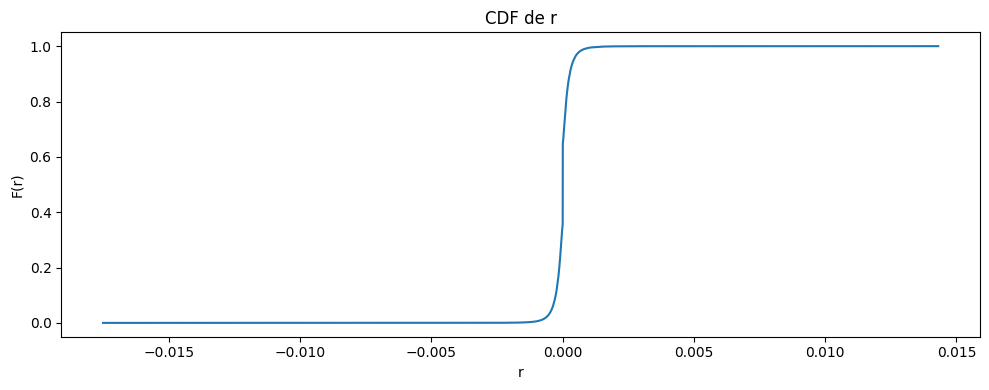

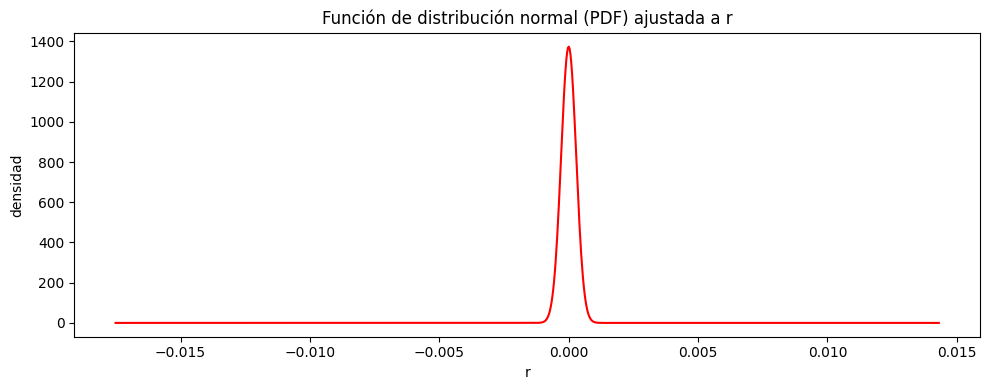

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df10["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df10["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1439043664947526
P0 (eps): 0.1439043664947526
d0 : -0.017512038025767396
d1 : -0.00026676758983050773
d2 : -0.00012998375213797424
d3 : -4.888213497800108e-05
d4 : -1.5214678050767816e-07
Percentiles mas bajos:
d0 : -0.000854486308155753
d1 : -0.000645734699226395
d2 : -0.0005390897518383965
d3 : -0.0004700230208456908
d4 : -0.0004183450730125564
d5 : -0.0003775342728461446
d6 : -0.00034357402190052965
d7 : -0.00031483460462096246
d8 : -0.0002906188743912175
d9 : -0.00026881898455356177
d10 : -0.00024906474155925553
d11 : -0.00023131452405531405
d12 : -0.00021492791995813933
d13 : -0.00020014203351529858
d14 : -0.00018672244063683863
d15 : -0.00017414237610395843
d16 : -0.0001623032359190688
d17 : -0.00015130968265464163
d18 : -0.00014103674458149128
d19 : -0.00013092374512962477


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.863120          0.136880        0.018851   
1    sym6  3      0.862229          0.137771        0.028615   
2     db6  3      0.862821          0.137179        0.029370   
3    sym4  3      0.862455          0.137545        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        0.980421   788.172962  
1             0.003599        0.976053  1527.291776  
2             0.003750        0.976940  1623.675248  
3             0.003572        0.974309  1625.363930  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.15530536 0.29846131 0.54623333]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 6)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  6      0.983487          0.016513        0.018851   
1    sym6  6      0.983535          0.016465        0.028615   
2     db6  6      0.983684          0.016316        0.029370   
3    sym4  6      0.983506          0.016494        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        1.349098   788.172962  
1             0.003599        1.346415  1527.291776  
2             0.003750        1.346673  1623.675248  
3             0.003572        1.344478  1625.363930  

Wavelet sugerida: db4 con J = 6

Energía por nivel (J...1) para el mejor wavelet:
[0.00458471 0.00918803 0.01832132 0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.01748336 0.03503767 0.06986659 0.13629791 0.26193334 0.47938114]


###VPN j=3 *

In [ ]:
#posible normalizacion o para GAT

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df10["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.863120          0.136880        0.018851   
1    sym6  3      0.862229          0.137771        0.028615   
2     db6  3      0.862821          0.137179        0.029370   
3    sym4  3      0.862455          0.137545        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        0.980421   788.172962  
1             0.003599        0.976053  1527.291776  
2             0.003750        0.976940  1623.675248  
3             0.003572        0.974309  1625.363930  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.15530536 0.29846131 0.54623333]


In [ ]:
df10["RV_r"] = df10["r"]**2

Energia local suavizada

In [ ]:
import numpy as np
import pandas as pd
import pywt
from scipy.signal import lfilter

def get_modwt_final_boss(df, col, w_name="db4", J=3):
    """
    MODWT Causal con Normalización de Percival & Walden,
    Notación Científica y Validación de Energía Ortogonal.
    """
    # 1. Preparación de datos
    x = df[col].fillna(0.0).values
    n = len(x)

    wavelet = pywt.Wavelet(w_name)
    h_base = wavelet.dec_hi / np.sqrt(2)
    g_base = wavelet.dec_lo / np.sqrt(2)
    L = len(h_base)

    current_a = x
    res_cols = []

    # 2. Descomposición Multinivel Causal
    for j in range(1, J + 1):
        step = 2**(j-1)
        # Dilatación del filtro (Algoritmo à trous)
        h_dil = np.zeros(L + (L - 1) * (step - 1))
        g_dil = np.zeros(L + (L - 1) * (step - 1))
        h_dil[::step] = h_base
        g_dil[::step] = g_base

        # Filtrado LFilter (Causalidad garantizada por Scipy)
        wj = lfilter(h_dil, [1.0], current_a)
        vj = lfilter(g_dil, [1.0], current_a)

        df[f"j{j}"] = wj
        res_cols.append(f"j{j}")
        current_a = vj

    df[f"a{J}"] = current_a
    res_cols.append(f"a{J}")

    # 3. Embargo y Auditoría Científica
    max_warmup = (L - 1) * (2**J - 1)

    # Limpiamos bordes para el test
    clean_df = df.iloc[max_warmup:].copy().dropna()

    if len(clean_df) > 100:
        # Usamos el mismo segmento para X y para los Coeficientes
        x_clean = x[max_warmup:max_warmup + len(clean_df)]

        var_x = np.var(x_clean, ddof=1)
        var_coeffs = clean_df[res_cols].var(ddof=1).sum()

        # Imprimir con precisión científica para evitar el "redondeo a cero"
        print("🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):")
        print(f"   Varianza Original (Var(x)): {var_x:.8e}")
        print(f"   Suma Varianzas (ΣVar):      {var_coeffs:.8e}")

        error_rel = np.abs(var_x - var_coeffs) / var_x if var_x > 0 else 0
        print(f"   Error Relativo:             {error_rel:.4%}")

        # Test de correlación (para demostrar que los niveles capturan info distinta)
        avg_corr = clean_df[res_cols].corr().abs().values[np.triu_indices(len(res_cols), k=1)].mean()
        print(f"   Correlación Media Inter-Nivel: {avg_corr:.4f}")

    # Aplicar NaNs de seguridad en el DataFrame original
    for col_res in res_cols:
        df.loc[df.index[:max_warmup], col_res] = np.nan

    return df

# Ejecución
df10 = get_modwt_final_boss(df10, "r", w_name="db4", J=3)

🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):
   Varianza Original (Var(x)): 8.43195300e-08
   Suma Varianzas (ΣVar):      8.43196235e-08
   Error Relativo:             0.0001%
   Correlación Media Inter-Nivel: 0.0014


In [ ]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 10 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   RV_r      float64       
 6   j1        float64       
 7   j2        float64       
 8   j3        float64       
 9   a3        float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 241.3 MB


In [ ]:
for j in range(1, 4):
    c = df10[f"j{j}"]
    df10[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

In [ ]:
df10["es"] = df10["js1"]
df10["em"] = df10["js2"]
df10["el"] = df10["js3"]

In [ ]:
df10["e_d"] = df10["es"] + df10["em"] + df10["el"]
s = df10["e_d"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 49


In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_d"])
df10["erm"] = np.log((df10["em"]) / df10["e_d"])
df10["erl"] = np.log((df10["el"]) / df10["e_d"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["vol_wlt"] = np.sqrt(df10["e_d"])

In [ ]:
s = df10["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 49


In [ ]:
df10["log_vol_wlt"] = np.log(df10["vol_wlt"])

In [ ]:
df10["as3"] = (df10["a3"] * df10["a3"]).rolling(3, min_periods=1).mean()
df10["e_total"] = df10["es"] + df10["em"] + df10["el"] + df10["as3"]

In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_total"])
df10["erm"] = np.log((df10["em"]) / df10["e_total"])
df10["erl"] = np.log((df10["el"]) / df10["e_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["tvol_wlt"] = np.sqrt(df10["e_total"])

In [ ]:
s = df10["tvol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 49


In [ ]:
df10["tlog_vol_wlt"] = np.log(df10["tvol_wlt"])

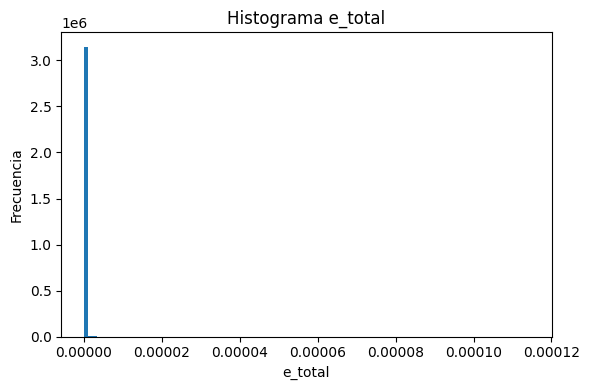

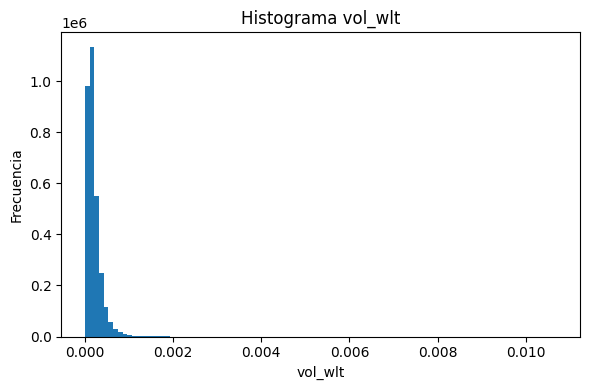

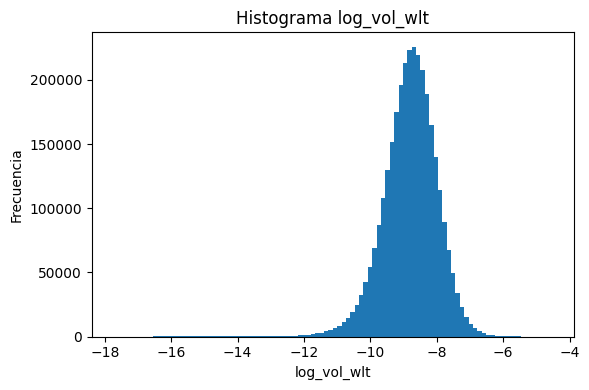

In [ ]:
import matplotlib.pyplot as plt

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df10["e_d"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-08-22 20:38:40
Fin   : 2024-08-22 20:43:40


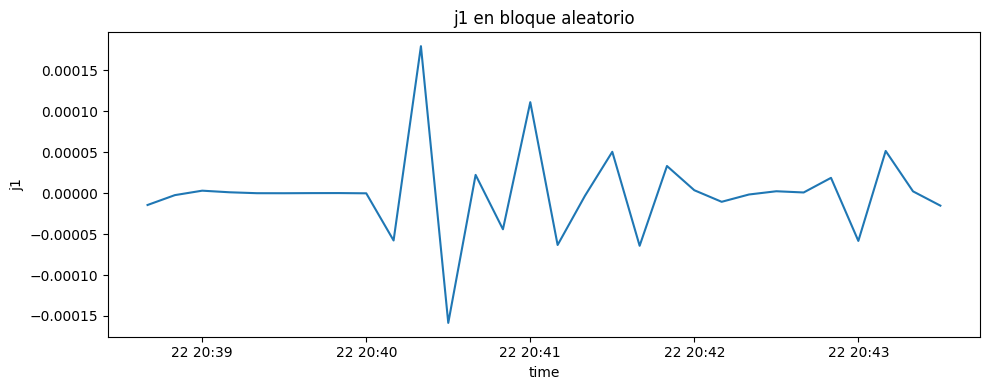

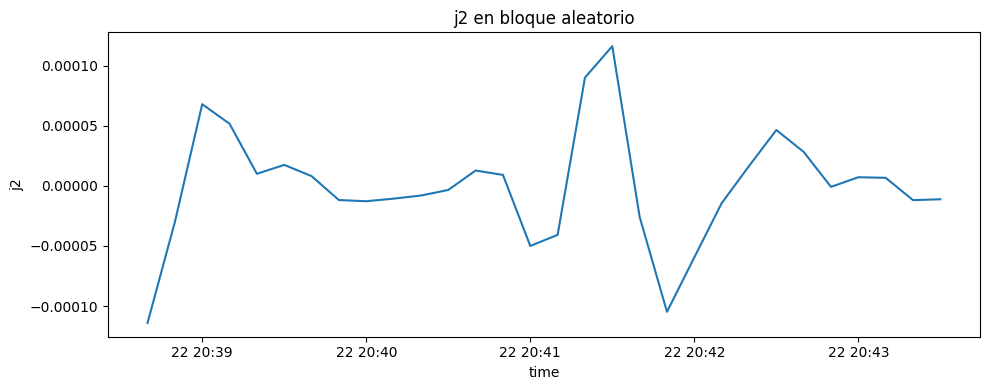

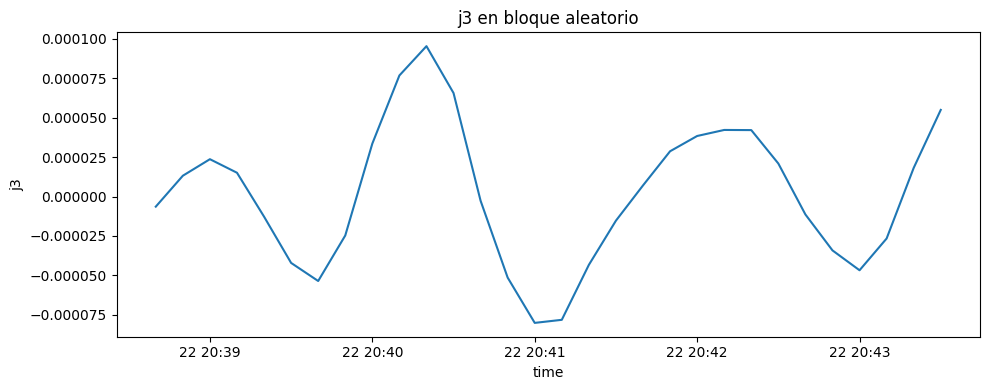

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 4)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-11-19 13:01:46
Fin   : 2024-11-19 13:06:46


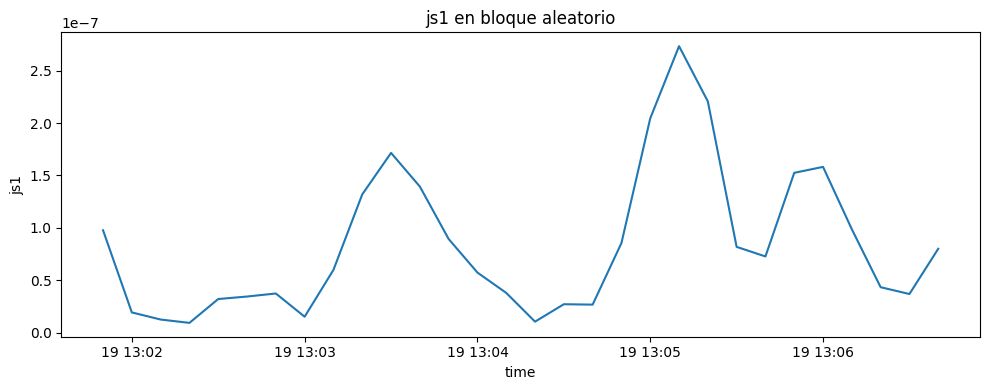

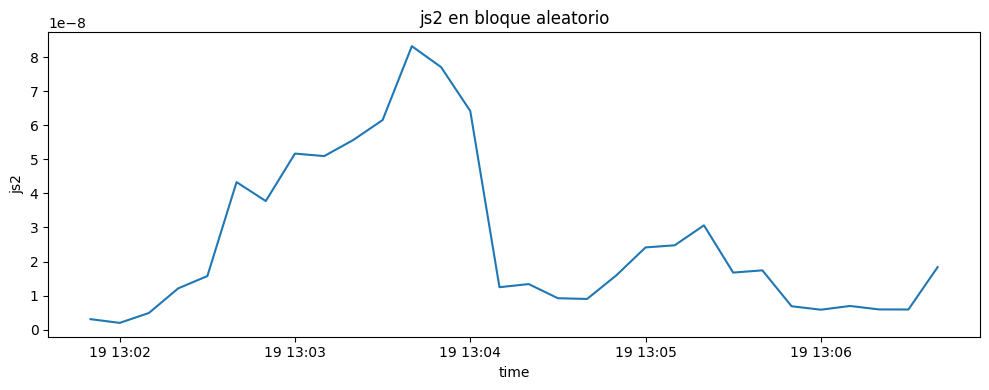

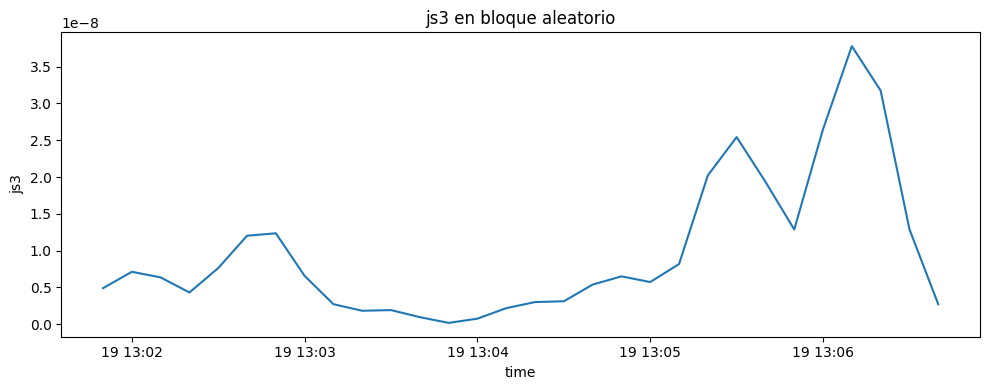

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 4)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()

*Eshort, Emedium and ELong all RAW*

In [ ]:
df10["des"] = df10["j1"]
df10["dem"] = df10["j2"]
df10["del"] = df10["j3"]

In [ ]:
s = df10["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df10["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df10["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 878
des Nulls: 49
dem Ceros: 0
dem Nulls: 49
del Ceros: 0
del Nulls: 49


In [ ]:
df10["de_total"] = df10["des"] + df10["dem"] + df10["del"]

In [ ]:
df10["dvol_wlt"] = np.sqrt(df10["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["dlog_vol_wlt"] = np.log(df10["dvol_wlt"])

***Signature Plot***

/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


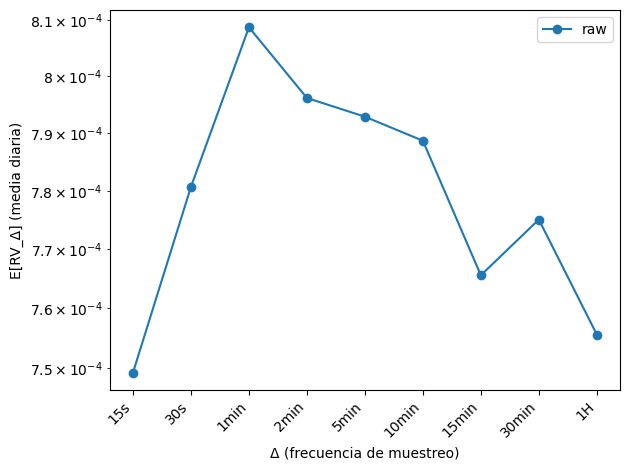

In [ ]:
  #signature plot estandar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def signature_rv_15s(
    df,
    t="time",
    logp="close_ln",
    deltas=("15s","30s","1min","2min","5min","10min","15min","30min","1H")
):
    x = df[[t, logp]].dropna().copy()
    x = x.sort_values(t).set_index(t)

    out = []
    for d in deltas:
        lp = x[logp].resample(d).last().dropna()
        r  = lp.diff().dropna()

        rv_block = r.pow(2).groupby(r.index.floor("D")).sum()
        out.append((d, rv_block.mean(), rv_block.median(), rv_block.size))

    return pd.DataFrame(out, columns=["delta","RV_mean","RV_median","n_days"])


sig_raw = signature_rv_15s(df10)

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ] (media diaria)")
ax.set_xlabel("Δ (frecuencia de muestreo)")
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()
/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


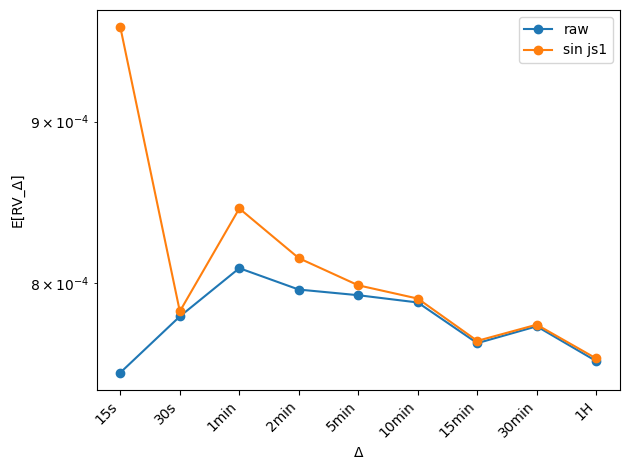

In [ ]:
def add_clean_logprice_15s(
    df,
    t="time",
    logp="close_ln",
    r="r",
    j1="j1",
    out="close_ln_clean"
):
    x = df[[t, logp, r, j1]].dropna().copy()
    x = x.sort_values(t)

    r_clean = (x[r] - x[j1]).to_numpy()
    x[out] = x[logp].iloc[0] + np.cumsum(r_clean)

    return x


df15_clean = add_clean_logprice_15s(df10)

sig_raw   = signature_rv_15s(df15_clean, logp="close_ln")
sig_clean = signature_rv_15s(df15_clean, logp="close_ln_clean")

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.plot(sig_clean["RV_mean"].to_numpy(), marker="o", label="sin js1")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ]")
ax.set_xlabel("Δ")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def explosion_score(sig, k=5):
    y = np.log(sig["RV_mean"].to_numpy())
    x = np.log(np.arange(1, len(y) + 1))
    return (y[k] - y[0]) / (x[k] - x[0])

score_raw   = explosion_score(sig_raw)
score_clean = explosion_score(sig_clean)

score_raw, score_clean

(np.float64(0.02858545655243811), np.float64(-0.11057700345805258))

####SHAP

**1 min**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1 min = 6 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 6 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 6 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=6, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=6, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 7 | Test[527037:1054067]
   Fold 2: Train[49:1054061] | Gap: 7 | Test[1054068:1581098]
   Fold 3: Train[49:1581092] | Gap: 7 | Test[1581099:2108129]
   Fold 4: Train[49:2108123] | Gap: 7 | Test[2108130:2635160]
   Fold 5: Train[49:2635154] | Gap: 7 | Test[2635161:3162191]


In [ ]:
horizon = 6
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.602833  0.217362  0.466221  0.361399  0.610131  527022
1     2  0.646733  0.308256  0.555208  0.409706  0.657711  527022
2     3  0.611405  0.213361  0.461910  0.357258  0.612767  527022
3     4  0.637971  0.244146  0.494112  0.374735  0.640682  527022
4     5  0.594061  0.200768  0.448072  0.348750  0.596056  527022

PROMEDIO:
R2      0.618601
MSE     0.236779
RMSE    0.485105
MAE     0.370369
EVS     0.623469
dtype: float64


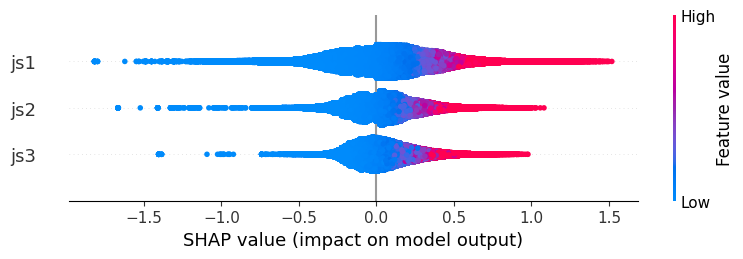

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**1 min navie**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.583386  0.228005  0.477499  0.370602  0.593654  527022
1     2  0.599950  0.349078  0.590829  0.422588  0.613252  527022
2     3  0.595198  0.222260  0.471444  0.364839  0.597902  527022
3     4  0.613553  0.260614  0.510504  0.385150  0.616262  527022
4     5  0.576158  0.209622  0.457845  0.356546  0.580161  527022

PROMEDIO:
R2      0.593649
MSE     0.253916
RMSE    0.501624
MAE     0.379945
EVS     0.600246
dtype: float64


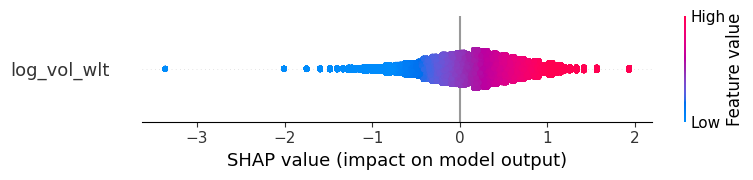

In [ ]:

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE

 #NAVIE                            #NAVIE                              #NAVIE

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#

import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd


class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["log_vol_wlt"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)




```
# Esto tiene formato de código
```

**1 min navie +shifted(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.562103  0.239653  0.489543  0.380756  0.573569  527022
1     2  0.577736  0.368462  0.607011  0.435805  0.592650  527022
2     3  0.575461  0.233098  0.482802  0.374393  0.578514  527022
3     4  0.592881  0.274554  0.523979  0.396610  0.595916  527022
4     5  0.555691  0.219745  0.468770  0.365652  0.560182  527022

PROMEDIO:
R2      0.572774
MSE     0.267102
RMSE    0.514421
MAE     0.390643
EVS     0.580166
dtype: float64


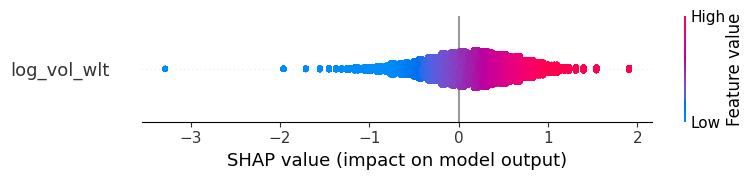

In [ ]:

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE

 #NAVIE                            #NAVIE                              #NAVIE

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#

import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd


class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["log_vol_wlt"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49
# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

**1 min + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.579566  0.230095  0.479683  0.372951  0.588125  527022
1     2  0.621642  0.330150  0.574586  0.424404  0.634267  527022
2     3  0.589996  0.225117  0.474465  0.367993  0.591617  527022
3     4  0.615366  0.259390  0.509304  0.387249  0.618405  527022
4     5  0.571681  0.211837  0.460258  0.359030  0.574026  527022

PROMEDIO:
R2      0.595650
MSE     0.251318
RMSE    0.499659
MAE     0.382325
EVS     0.601288
dtype: float64


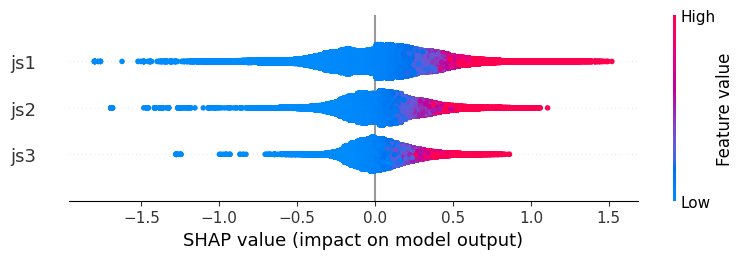

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49  # 6*10s = 1 min

# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**HF**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1/6 min = 1 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 1 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 1 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=1, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 1/6 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=1, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 2 | Test[527032:1054062]
   Fold 2: Train[49:1054061] | Gap: 2 | Test[1054063:1581093]
   Fold 3: Train[49:1581092] | Gap: 2 | Test[1581094:2108124]
   Fold 4: Train[49:2108123] | Gap: 2 | Test[2108125:2635155]
   Fold 5: Train[49:2635154] | Gap: 2 | Test[2635156:3162186]


In [ ]:
horizon = 1
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.814572  0.101481  0.318560  0.246697  0.815218  527023
1     2  0.851441  0.129633  0.360046  0.267857  0.853034  527023
2     3  0.814612  0.101786  0.319038  0.246578  0.814680  527023
3     4  0.836026  0.110584  0.332541  0.254370  0.836510  527023
4     5  0.802099  0.097876  0.312852  0.242405  0.802151  527023

PROMEDIO:
R2      0.823750
MSE     0.108272
RMSE    0.328608
MAE     0.251581
EVS     0.824319
dtype: float64


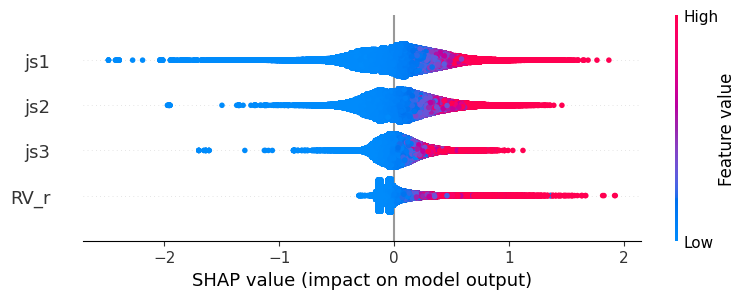

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3","RV_r"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.773240  0.124101  0.352279  0.269738  0.774945  527023
1     2  0.809565  0.166174  0.407644  0.298799  0.812447  527023
2     3  0.774529  0.123793  0.351842  0.269233  0.774775  527023
3     4  0.796733  0.137083  0.370247  0.279619  0.797528  527023
4     5  0.761888  0.117763  0.343167  0.263805  0.762283  527023

PROMEDIO:
R2      0.783191
MSE     0.133783
RMSE    0.365036
MAE     0.276239
EVS     0.784396
dtype: float64


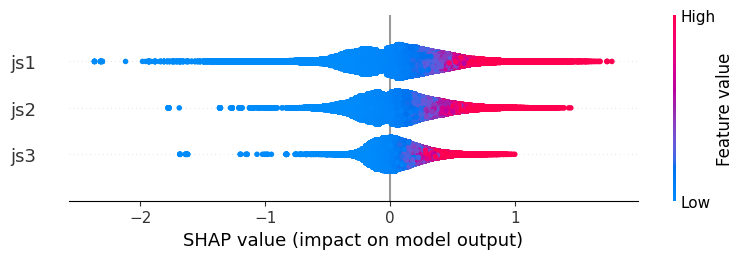

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

**10 segs + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.672049  0.179480  0.423651  0.328483  0.676240  527023
1     2  0.724269  0.240603  0.490513  0.365421  0.730650  527023
2     3  0.675613  0.178102  0.422021  0.326740  0.676291  527023
3     4  0.705841  0.198380  0.445399  0.340075  0.707680  527023
4     5  0.658663  0.168816  0.410873  0.319779  0.659730  527023

PROMEDIO:
R2      0.687287
MSE     0.193076
RMSE    0.438491
MAE     0.336100
EVS     0.690118
dtype: float64


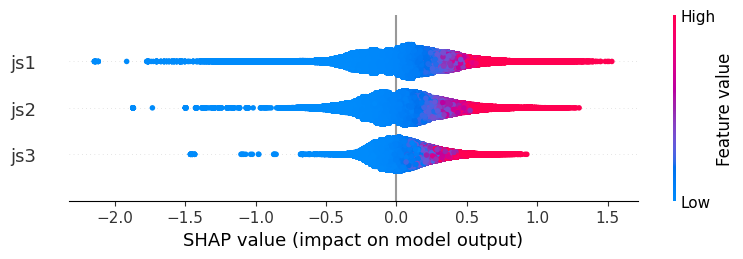

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49  # 6*10s = 1 min

# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**2 min**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 2 min = 12 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 12 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 12 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=12, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=12, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 13 | Test[527043:1054073]
   Fold 2: Train[49:1054061] | Gap: 13 | Test[1054074:1581104]
   Fold 3: Train[49:1581092] | Gap: 13 | Test[1581105:2108135]
   Fold 4: Train[49:2108123] | Gap: 13 | Test[2108136:2635166]
   Fold 5: Train[49:2635154] | Gap: 13 | Test[2635167:3162197]


In [ ]:
horizon = 12
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.485294  0.281690  0.530745  0.414707  0.499266  527021
1     2  0.499133  0.437042  0.661091  0.480747  0.520387  527021
2     3  0.500285  0.274400  0.523832  0.407174  0.503656  527021
3     4  0.511704  0.329283  0.573832  0.434338  0.516438  527021
4     5  0.483764  0.255319  0.505291  0.395159  0.488626  527021

PROMEDIO:
R2      0.496036
MSE     0.315547
RMSE    0.558958
MAE     0.426425
EVS     0.505675
dtype: float64


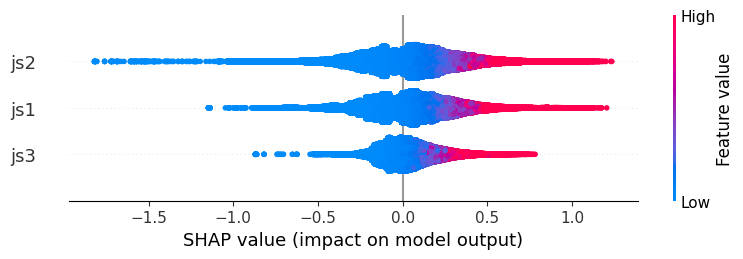

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 12, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**5 min**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 5 min = 30 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 30 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 30 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=30, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 5 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=30, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 31 | Test[527061:1054091]
   Fold 2: Train[49:1054061] | Gap: 31 | Test[1054092:1581122]
   Fold 3: Train[49:1581092] | Gap: 31 | Test[1581123:2108153]
   Fold 4: Train[49:2108123] | Gap: 31 | Test[2108154:2635184]
   Fold 5: Train[49:2635154] | Gap: 31 | Test[2635185:3162215]


In [ ]:
horizon = 30
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.419182  0.317875  0.563804  0.440681  0.437899  527018
1     2  0.360311  0.558145  0.747091  0.522204  0.398144  527018
2     3  0.430153  0.312997  0.559461  0.433516  0.434810  527018
3     4  0.419479  0.391417  0.625633  0.464399  0.427726  527018
4     5  0.427119  0.283336  0.532293  0.415484  0.432294  527018

PROMEDIO:
R2      0.411249
MSE     0.372754
RMSE    0.605657
MAE     0.455257
EVS     0.426175
dtype: float64


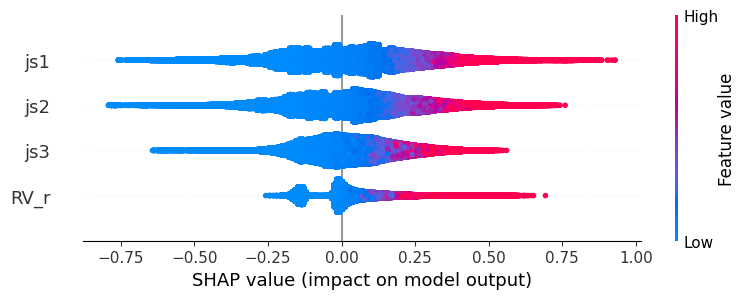

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3","RV_r"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 30, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


In [ ]:
# TOP HORIZONTES
# 1 MINUTO *
# 2 MINUTOS

#### SHAP REGIMENES

**1 minuto**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1 min = 6 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_min = 6

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 6 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=6, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=6, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 7 | Test[527037:1054067]
   Fold 2: Train[49:1054061] | Gap: 7 | Test[1054068:1581098]
   Fold 3: Train[49:1581092] | Gap: 7 | Test[1581099:2108129]
   Fold 4: Train[49:2108123] | Gap: 7 | Test[2108130:2635160]
   Fold 5: Train[49:2635154] | Gap: 7 | Test[2635161:3162191]


In [ ]:
horizon = 6
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

**1 min + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.549292  0.246664  0.496653  0.387814  0.559376  527022
1     2  0.588888  0.358730  0.598940  0.443133  0.603707  527022
2     3  0.561238  0.240909  0.490825  0.382031  0.563211  527022
3     4  0.585668  0.279417  0.528599  0.403324  0.589191  527022
4     5  0.542651  0.226195  0.475599  0.372230  0.545765  527022

PROMEDIO:
R2      0.565548
MSE     0.270383
RMSE    0.518123
MAE     0.397706
EVS     0.572250
dtype: float64


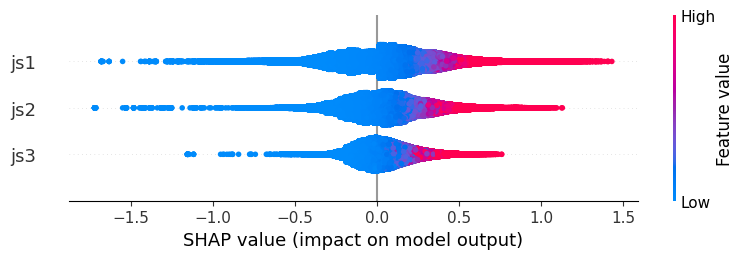

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49  # 6*10s = 1 min

# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


/tmp/ipython-input-3688304185.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  regime_metrics = analysis.groupby('Regime', observed=True).apply(lambda x: pd.Series({
/tmp/ipython-input-3688304185.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Regime', y='Error', data=analysis, palette='viridis')


📊 MÉTRICAS POR RÉGIMEN DE VOLATILIDAD:
                  R2       MAE      Bias     Count
Regime                                            
Baja        0.200900  0.428260  0.073286  105405.0
Media-Baja  0.000434  0.368066 -0.003067  105404.0
Media      -0.034229  0.353819 -0.044512  105404.0
Media-Alta -0.073792  0.351280 -0.085040  105404.0
Alta        0.039384  0.359724 -0.136883  105405.0


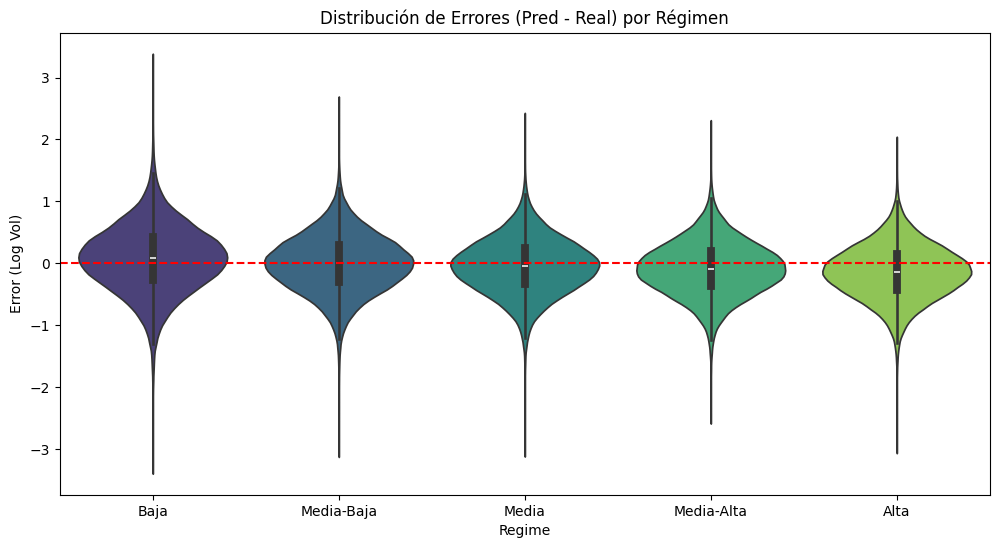

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperamos la volatilidad actual para el último fold de test
# Asumimos que 'log_vol_now' está alineada con 'last_Xte'
vol_now_test = df10.loc[last_Xte.index, "log_vol_wlt"]

# 2. Creamos los 5 regímenes basados en quintiles
regime_labels = ['Baja', 'Media-Baja', 'Media', 'Media-Alta', 'Alta']
regimes = pd.qcut(vol_now_test, 5, labels=regime_labels)

# 3. Construimos el DataFrame de análisis de residuos
analysis = pd.DataFrame({
    'Real': last_yte,
    'Pred': last_model.predict(last_Xte),
    'Regime': regimes
})
analysis['Error'] = analysis['Pred'] - analysis['Real']
analysis['AbsError'] = analysis['Error'].abs()

# 4. Cálculo de métricas por régimen
regime_metrics = analysis.groupby('Regime', observed=True).apply(lambda x: pd.Series({
    'R2': r2_score(x['Real'], x['Pred']),
    'MAE': x['AbsError'].mean(),
    'Bias': x['Error'].mean(),
    'Count': len(x)
}))

print("📊 MÉTRICAS POR RÉGIMEN DE VOLATILIDAD:")
print(regime_metrics)

# 5. Visualización de la "Firma del Error"
plt.figure(figsize=(12, 6))
sns.violinplot(x='Regime', y='Error', data=analysis, palette='viridis')
plt.axhline(0, color='red', linestyle='--')
plt.title('Distribución de Errores (Pred - Real) por Régimen')
plt.ylabel('Error (Log Vol)')
plt.show()

In [ ]:
# el modelo es mas preciso en los extremos, el R2 no es importante por la microvarianza inherente al experimento
# Posibles complementos
# 1. modelo truncado
# 2. Wavelet mas larga Js


# complemento indispensable:
# rolling explosition score from signature plot, a 1 hora, 2 horas, o algo asi

####Blocks minutes

15 minutes

In [ ]:
import numpy as np
import pandas as pd

df10["time"] = pd.to_datetime(df10["time"])
df_ = df10.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("15T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("15T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-579726812.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("15T").mean()
/tmp/ipython-input-579726812.py:20: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("15T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.9680888580133168
Spearman: 0.9939164975878483
Kendall : 0.9386851373170828


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.46401975838952175
Spearman: 0.9939164975878483
Kendall : 0.9386851373170828


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "de_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["de_total"], method="pearson")
spearman = s["RV_r"].corr(s["de_total"], method="spearman")
kendall  = s["RV_r"].corr(s["de_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.027596908554682657
Spearman: -0.0036246700253256656
Kendall : -0.001563653905324324


5 minutes

In [ ]:
import numpy as np
import pandas as pd

df10["time"] = pd.to_datetime(df10["time"])
df_ = df10.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("5T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-1207572129.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("5T").mean()
/tmp/ipython-input-1207572129.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.9133079979737936
Spearman: 0.969115585222217
Kendall : 0.8545449970438539


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.969115585222217
Kendall : 0.8545449970438539


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "de_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["de_total"], method="pearson")
spearman = s["RV_r"].corr(s["de_total"], method="spearman")
kendall  = s["RV_r"].corr(s["de_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : -0.0010241392789214739
Spearman: 0.00013647665772086634
Kendall : 0.00017855244669816493


3 min

In [ ]:
import numpy as np
import pandas as pd

df10["time"] = pd.to_datetime(df10["time"])
df_ = df10.set_index("time")

# 1) Mean por defecto
df2m = df_.resample("3T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "des","dem","del","e_d",
    "ers","erm","erl",
    "de_total"
]

df2m[sum_cols] = df_[sum_cols].resample("3T").sum()
df2m = df2m.reset_index()

/tmp/ipython-input-3912748737.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df2m = df_.resample("3T").mean()
/tmp/ipython-input-3912748737.py:20: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df2m[sum_cols] = df_[sum_cols].resample("3T").sum()


In [ ]:
df2m["vol_wlt"]      = np.sqrt(df2m["e_d"])
df2m["log_vol_wlt"]  = np.log(df2m["vol_wlt"])

df2m["tvol_wlt"]     = np.sqrt(df2m["e_total"])
df2m["tlog_vol_wlt"] = np.log(df2m["tvol_wlt"])

df2m["dvol_wlt"]     = np.sqrt(df2m["de_total"])
df2m["dlog_vol_wlt"] = np.log(df2m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df2m[["RV_r", "de_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["de_total"], method="pearson")
spearman = s["RV_r"].corr(s["de_total"], method="spearman")
kendall  = s["RV_r"].corr(s["de_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : -0.011193769692404645
Spearman: -0.003569211483118735
Kendall : -0.002275384429561592


In [ ]:
# Limpieza mínima
s = df2m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.9353405459559405
Kendall : 0.78589521156818


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [ ]:
# Limpieza mínima
s = df2m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.8481902851825189
Spearman: 0.9353405459559405
Kendall : 0.78589521156818


2 min

In [ ]:
import numpy as np
import pandas as pd

df10["time"] = pd.to_datetime(df10["time"])
df_ = df10.set_index("time")

# 1) Mean por defecto
df2m = df_.resample("2T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "des","dem","del","e_d",
    "ers","erm","erl",
    "de_total"
]

df2m[sum_cols] = df_[sum_cols].resample("2T").sum()
df2m = df2m.reset_index()

/tmp/ipython-input-653724807.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df2m = df_.resample("2T").mean()
/tmp/ipython-input-653724807.py:20: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df2m[sum_cols] = df_[sum_cols].resample("2T").sum()


In [ ]:
df2m["vol_wlt"]      = np.sqrt(df2m["e_d"])
df2m["log_vol_wlt"]  = np.log(df2m["vol_wlt"])

df2m["tvol_wlt"]     = np.sqrt(df2m["e_total"])
df2m["tlog_vol_wlt"] = np.log(df2m["tvol_wlt"])

df2m["dvol_wlt"]     = np.sqrt(df2m["de_total"])
df2m["dlog_vol_wlt"] = np.log(df2m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df2m[["RV_r", "de_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["de_total"], method="pearson")
spearman = s["RV_r"].corr(s["de_total"], method="spearman")
kendall  = s["RV_r"].corr(s["de_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.010545759872311475
Spearman: 0.00038857290957007204
Kendall : 0.00023080499466974182


In [ ]:
# Limpieza mínima
s = df2m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.900051735432573
Kendall : 0.7300094094262011


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [ ]:
# Limpieza mínima
s = df2m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.7717496538605985
Spearman: 0.900051735432573
Kendall : 0.7300094094262011


1 min

In [ ]:
import numpy as np
import pandas as pd

df10["time"] = pd.to_datetime(df10["time"])
df_ = df10.set_index("time")

# 1) Mean por defecto
df1m = df_.resample("1T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "des","dem","del","e_d",
    "ers","erm","erl",
    "de_total"
]

df1m[sum_cols] = df_[sum_cols].resample("1T").sum()
df1m = df1m.reset_index()

/tmp/ipython-input-3794388351.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df1m = df_.resample("1T").mean()
/tmp/ipython-input-3794388351.py:20: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df1m[sum_cols] = df_[sum_cols].resample("1T").sum()


In [ ]:
# df1m["vol_wlt"]      = np.sqrt(df1m["e_d"])
# df1m["log_vol_wlt"]  = np.log(df1m["vol_wlt"])

# df1m["tvol_wlt"]     = np.sqrt(df1m["e_total"])
# df1m["tlog_vol_wlt"] = np.log(df1m["tvol_wlt"])

df1m["dvol_wlt"]     = np.sqrt(df1m["de_total"])
df1m["dlog_vol_wlt"] = np.log(df1m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df1m[["RV_r", "de_total"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["de_total"], method="pearson")
spearman = s["RV_r"].corr(s["de_total"], method="spearman")
kendall  = s["RV_r"].corr(s["de_total"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : -0.0016479271564138218
Spearman: -0.00011621706071594414
Kendall : -5.078094697082513e-05


In [ ]:
# Limpieza mínima
s = df1m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.23037396622466266
Spearman: 0.8039669998662509
Kendall : 0.6123008307606109


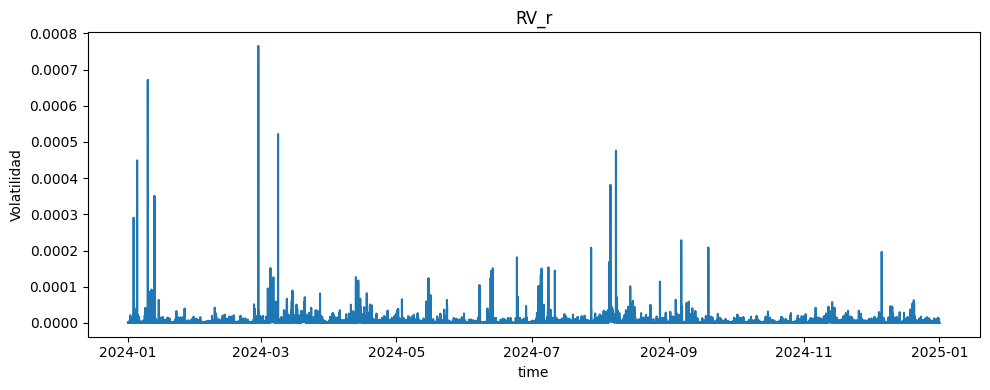

In [ ]:
s = df15m["RV_r"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("RV_r")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

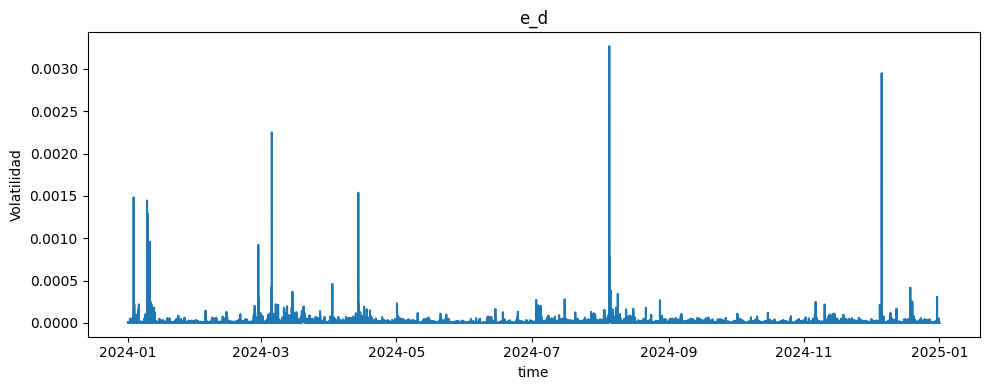

In [ ]:
s = df15m["e_d"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("e_d")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

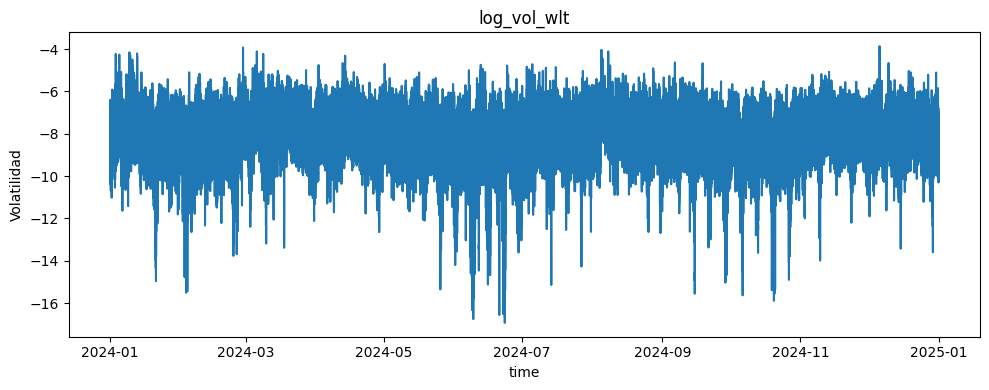

In [ ]:
s = df15["log_vol_wlt"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15.loc[s.index, "time"], s.values)
plt.title("log_vol_wlt")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

***Test iniciales***

In [ ]:
import pandas as pd

x = df15m["vol_wlt"]
r = df15m["r"]

corr_t   = x.corr(r)
corr_tp1 = x.corr(r.shift(-1))

corr_t, corr_tp1

(np.float64(0.009346382080625977), np.float64(0.0037274259736032457))

In [ ]:
#no hay leakage

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lags = [5, 10, 20]

lb_js = {
    f"js{i}": acorr_ljungbox(df15m[f"js{i}"].dropna(), lags=lags, return_df=True)
    for i in [1, 2, 3]
}

lb_js

{'js1':          lb_stat  lb_pvalue
 5   54999.562312        0.0
 10  73851.169901        0.0
 20  92422.459761        0.0,
 'js2':          lb_stat  lb_pvalue
 5   49174.384471        0.0
 10  62040.193222        0.0
 20  74858.937948        0.0,
 'js3':          lb_stat  lb_pvalue
 5   35530.265008        0.0
 10  44092.392903        0.0
 20  51618.090716        0.0}

In [ ]:
#La volatilidad wavelet no es un artefacto de microestructura.
# POR LO TANTO; la vairable no es una varianza fisica sino es un estado latente de intensidad

In [ ]:
import numpy as np

targets = df15m["RV_r"]

corr_levels = {
    "js1": df15m["js1"].corr(targets),
    "js2": df15m["js2"].corr(targets),
    "js3": df15m["js3"].corr(targets),
}

corr_levels

{'js1': np.float64(0.4119542112895267),
 'js2': np.float64(0.4066213093031348),
 'js3': np.float64(0.4400764387086965)}

In [ ]:
#La señal es multiescala, no un truco de j1, por lo cual no es imprecindible

In [ ]:
vol_23 = np.sqrt(df15m["js2"]**2 + df15m["js3"]**2)
vol_23 = np.log(vol_23.replace(0, np.nan))

vol_23.corr(targets)

np.float64(0.2973378807779419)

In [ ]:
#Spearman alto es legítimo, no inflado artificialmente.

In [ ]:
# CONCLUSION
# Si la querés target en un GAT, hacelo ordinal (bins) y entrená para:

# alta Kendall/Spearman out-of-sample,

# estabilidad rolling,

# y consistencia de edges en ventanas.

# La versión “continua con MSE” es posible, pero es pelearte con la geometría equivocada: como medir temperatura con una regla.

# Si me decís cuántos activos y qué frecuencia (5m / 15m), te propongo la definición mínima de:

# nodos/features,

# edges (qué medida usar),

# y el head ordinal (K y thresholds) para que quede coherente con tu proxy.

In [ ]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 120.6 MB


## r_5 *


In [ ]:
df5 = btc.iloc[:, [0, 1, 5, 12]]
df5 = df5.iloc[::5].copy()
df5["r"] = df5["close_ln"].diff()
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6324480 entries, 0 to 31622395
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 241.3 MB


Media: 1.25603265690571e-07
Mediana: 0.0
Moda: 0.0
Desvío estándar: 0.00019855457352692087
Skew: -0.40834499325405255
Deciles:
d1 : -0.00017222389268987116
d2 : -6.859676887849275e-05
d3 : -2.1105924652431435e-07
d4 : 0.0
d5 : 0.0
d6 : 0.0
d7 : 2.077574510650489e-07
d8 : 6.932498129330615e-05
d9 : 0.00017277186968485126
Percentiles mas altos:
d95 : 0.0002812700723461958
d96 : 0.00031732933942947735
d97 : 0.0003665399943378135
d98 : 0.0004396937377519791
d99 : 0.0005776129701509085
d100 : 0.015451702569313497
Permiles
p970 : 0.0003665399943378135
p971 : 0.0003725686136276779
p972 : 0.000378945390521664
p973 : 0.0003854432825619723
p974 : 0.00039181474361512075
p975 : 0.0003988269326985257
p976 : 0.00040587727329213406
p977 : 0.0004136872350629731
p978 : 0.0004218373307861896
p979 : 0.0004305074507235906
p980 : 0.0004396937377519791
p981 : 0.00044954259129948186
p982 : 0.00045967398501489416
p983 : 0.00047038260175317955
p984 : 0.00048182564501215563
p985 : 0.0004944025489337456
p986 : 0

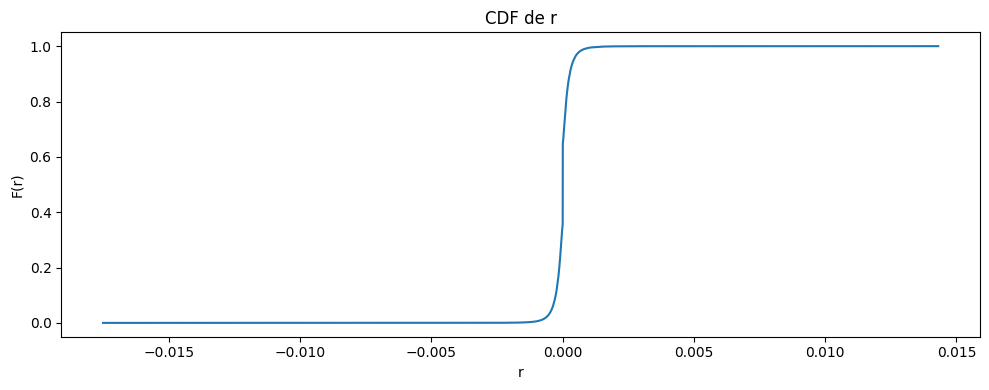

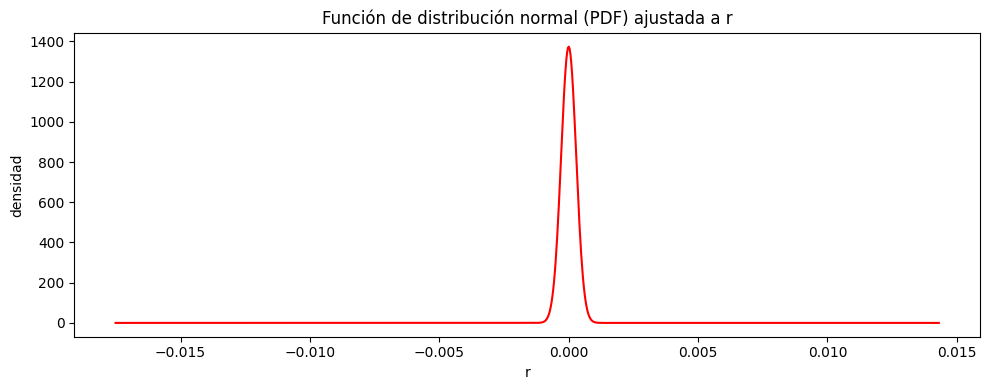

In [ ]:
import numpy as np
from scipy.stats import skew, norm

s = df5["r"].dropna()

media   = s.mean()
mediana = s.median()
moda    = s.mode().iloc[0] if not s.mode().empty else np.nan
sd      = s.std()
skw     = skew(s)

# 10 deciles (0.1, 0.2, ..., 0.9)
deciles = {f"d{int(p*10)}": s.quantile(p) for p in np.arange(0.1, 1.0, 0.1)}

print("Media:", media)
print("Mediana:", mediana)
print("Moda:", moda)
print("Desvío estándar:", sd)
print("Skew:", skw)
print("Deciles:")
for k, v in deciles.items():
    print(k, ":", v)

# TOP Percentiles, permiles, permisiles y fractiles
Percentiles = {f"d{int(p*100)}": s.quantile(p) for p in np.arange(0.95, 1.0, 0.01)}
print("Percentiles mas altos:")
for k, v in Percentiles.items():
    print(k, ":", v)
permiles = {f"p{int(p*1000)}": s.quantile(p)
            for p in np.arange(0.970, 1.001, 0.001)}

print("Permiles")
for k, v in permiles.items():
    print(k, ":", v)

permisiles = {f"p{int(p*10000)}": s.quantile(p)
            for p in np.arange(0.9970, 1.0000, 0.0001)}

print("permisiles")
for k, v in permisiles.items():
    print(k, ":", v)

fractales = {f"p{int(p*100000)}": s.quantile(p)
            for p in np.arange(0.99980, 1.00000, 0.00001)}

print("fractales")
for k, v in fractales.items():
    print(k, ":", v)



import numpy as np
import matplotlib.pyplot as plt

s = df10["r"].dropna().sort_values()

# CDF empírica
y = np.linspace(0, 1, len(s))

plt.figure(figsize=(10,4))
plt.plot(s.values, y)
plt.title("CDF de r")
plt.xlabel("r")
plt.ylabel("F(r)")
plt.tight_layout()
plt.show()



mu = s.mean()
sigma = s.std()

# Rango para graficar
x = np.linspace(s.min(), s.max(), 1000)

# PDF normal
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10,4))
plt.plot(x, pdf, label="Normal PDF", color="red")
plt.title("Función de distribución normal (PDF) ajustada a r")
plt.xlabel("r")
plt.ylabel("densidad")
plt.tight_layout()
plt.show()

In [ ]:
# masa central
p0 = (s == 0).mean()
eps = np.nextafter(0, 1)
p0_eps = (np.abs(s) <= eps).mean()
print("P0 (exacto):", p0)
print("P0 (eps):", p0_eps)

deciles = {f"d{int(p*10)}": np.quantile(s, p) for p in np.arange(0.0, 0.5, 0.1)}

for k, v in deciles.items():
    print(k, ":", v)

Percentiles = {f"d{int(p*100)}": np.quantile(s, p) for p in np.arange(0.00, 0.2, 0.001)}
print("Percentiles mas bajos:")
for k, v in Percentiles.items():
    print(k, ":", v)

# permiles = {f"p{int(p*1000)}": np.quantile(s, p)
#             for p in np.arange(0.000, 0.001, 0.0001)}

# print("Permiles")
# for k, v in permiles.items():
#     print(k, ":", v)

# permisiles = {f"p{int(p*10000)}": np.quantile(s, p)
#               for p in np.arange(0.0000, 0.0001, 0.00001)}

# print("permisiles")
# for k, v in permisiles.items():
#     print(k, ":", v)

P0 (exacto): 0.1439043664947526
P0 (eps): 0.1439043664947526
d0 : -0.017512038025767396
d1 : -0.00026676758983050773
d2 : -0.00012998375213797424
d3 : -4.888213497800108e-05
d4 : -1.5214678050767816e-07
Percentiles mas bajos:
d0 : -0.000854486308155753
d1 : -0.000645734699226395
d2 : -0.0005390897518383965
d3 : -0.0004700230208456908
d4 : -0.0004183450730125564
d5 : -0.0003775342728461446
d6 : -0.00034357402190052965
d7 : -0.00031483460462096246
d8 : -0.0002906188743912175
d9 : -0.00026881898455356177
d10 : -0.00024906474155925553
d11 : -0.00023131452405531405
d12 : -0.00021492791995813933
d13 : -0.00020014203351529858
d14 : -0.00018672244063683863
d15 : -0.00017414237610395843
d16 : -0.0001623032359190688
d17 : -0.00015130968265464163
d18 : -0.00014103674458149128
d19 : -0.00013092374512962477


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df5["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 3)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.854047          0.145953        0.013217   
1    sym6  3      0.854492          0.145508        0.020884   
2     db6  3      0.854113          0.145887        0.020906   
3    sym4  3      0.854634          0.145366        0.022173   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.002907        0.987935  1220.629673  
1             0.003318        0.986468  2115.544851  
2             0.003289        0.985231  2164.453623  
3             0.003342        0.985100  2234.346584  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.03408218 0.06414813 0.1147143 ]
Shares por nivel (J...1):
[0.16005184 0.30124327 0.53870488]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df5["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 5)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  5      0.963482          0.036518        0.013217   
1    sym6  5      0.963756          0.036244        0.020884   
2     db6  5      0.963863          0.036137        0.020906   
3    sym4  5      0.963707          0.036293        0.022173   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.002907        1.302006  1220.629673  
1             0.003318        1.300887  2115.544851  
2             0.003289        1.300704  2164.453623  
3             0.003342        1.299252  2234.346584  

Wavelet sugerida: db4 con J = 5

Energía por nivel (J...1) para el mejor wavelet:
[0.00911141 0.01817454 0.03408218 0.06414813 0.1147143 ]
Shares por nivel (J...1):
[0.03792776 0.07565457 0.14187278 0.26702736 0.47751753]


In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df5["r"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 4)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  4      0.926939          0.073061        0.013217   
1    sym6  4      0.926500          0.073500        0.020884   
2     db6  4      0.926336          0.073664        0.020906   
3    sym4  4      0.926653          0.073347        0.022173   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.002907        1.185675  1220.629673  
1             0.003318        1.182966  2115.544851  
2             0.003289        1.182190  2164.453623  
3             0.003342        1.181704  2234.346584  

Wavelet sugerida: db4 con J = 4

Energía por nivel (J...1) para el mejor wavelet:
[0.01817454 0.03408218 0.06414813 0.1147143 ]
Shares por nivel (J...1):
[0.0786371  0.14746583 0.27755438 0.49634269]


####V2j

In [ ]:
# Aplicamos modwlt sobre las js individualmente para su posterior agregacion y suavizado,
# asi como su uso en sujeto individual

In [ ]:
#                                                                                Inicio Acceso directo

**Energia local suavizada 1er orden**

In [ ]:
import numpy as np
import pandas as pd
import pywt
from scipy.signal import lfilter

def get_modwt_final_boss(df, col, w_name="db4", J=3):
    """
    MODWT Causal con Normalización de Percival & Walden,
    Notación Científica y Validación de Energía Ortogonal.
    """
    # 1. Preparación de datos
    x = df[col].fillna(0.0).values
    n = len(x)

    wavelet = pywt.Wavelet(w_name)
    h_base = wavelet.dec_hi / np.sqrt(2)
    g_base = wavelet.dec_lo / np.sqrt(2)
    L = len(h_base)

    current_a = x
    res_cols = []

    # 2. Descomposición Multinivel Causal
    for j in range(1, J + 1):
        step = 2**(j-1)
        # Dilatación del filtro (Algoritmo à trous)
        h_dil = np.zeros(L + (L - 1) * (step - 1))
        g_dil = np.zeros(L + (L - 1) * (step - 1))
        h_dil[::step] = h_base
        g_dil[::step] = g_base

        # Filtrado LFilter (Causalidad garantizada por Scipy)
        wj = lfilter(h_dil, [1.0], current_a)
        vj = lfilter(g_dil, [1.0], current_a)

        df[f"j{j}"] = wj
        res_cols.append(f"j{j}")
        current_a = vj

    df[f"a{J}"] = current_a
    res_cols.append(f"a{J}")

    # 3. Embargo y Auditoría Científica
    max_warmup = (L - 1) * (2**J - 1)

    # Limpiamos bordes para el test
    clean_df = df.iloc[max_warmup:].copy().dropna()

    if len(clean_df) > 100:
        # Usamos el mismo segmento para X y para los Coeficientes
        x_clean = x[max_warmup:max_warmup + len(clean_df)]

        var_x = np.var(x_clean, ddof=1)
        var_coeffs = clean_df[res_cols].var(ddof=1).sum()

        # Imprimir con precisión científica para evitar el "redondeo a cero"
        print("🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):")
        print(f"   Varianza Original (Var(x)): {var_x:.8e}")
        print(f"   Suma Varianzas (ΣVar):      {var_coeffs:.8e}")

        error_rel = np.abs(var_x - var_coeffs) / var_x if var_x > 0 else 0
        print(f"   Error Relativo:             {error_rel:.4%}")

        # Test de correlación (para demostrar que los niveles capturan info distinta)
        avg_corr = clean_df[res_cols].corr().abs().values[np.triu_indices(len(res_cols), k=1)].mean()
        print(f"   Correlación Media Inter-Nivel: {avg_corr:.4f}")

    # Aplicar NaNs de seguridad en el DataFrame original
    for col_res in res_cols:
        df.loc[df.index[:max_warmup], col_res] = np.nan

    return df

# Ejecución
df10 = get_modwt_final_boss(df5, "r", w_name="db4", J=5)

🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):
   Varianza Original (Var(x)): 3.94247793e-08
   Suma Varianzas (ΣVar):      3.94248231e-08
   Error Relativo:             0.0001%
   Correlación Media Inter-Nivel: 0.0013


In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6324480 entries, 0 to 31622395
Data columns (total 17 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   j1        float64       
 6   j2        float64       
 7   j3        float64       
 8   j4        float64       
 9   a4        float64       
 10  js1       float64       
 11  js2       float64       
 12  js3       float64       
 13  js4       float64       
 14  j5        float64       
 15  a5        float64       
 16  js5       float64       
dtypes: datetime64[ns](1), float64(15), int64(1)
memory usage: 820.3 MB


In [ ]:
for j in range(1, 6):
    c = df5[f"j{j}"]
    df5[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6324480 entries, 0 to 31622395
Data columns (total 17 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   j1        float64       
 6   j2        float64       
 7   j3        float64       
 8   j4        float64       
 9   a4        float64       
 10  js1       float64       
 11  js2       float64       
 12  js3       float64       
 13  js4       float64       
 14  j5        float64       
 15  a5        float64       
 16  js5       float64       
dtypes: datetime64[ns](1), float64(15), int64(1)
memory usage: 820.3 MB


***Energia local suavizada 2DO orden***

*J1*

In [ ]:
import numpy as np
import pandas as pd
import pywt

x = df5["js1"].dropna().to_numpy()
candidates = ["db4", "db6", "sym4", "sym6"]

def acf(x, max_lag=20):
    x = x - x.mean()
    denom = np.dot(x, x)
    acfs = []
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acfs.append(num / denom)
    return np.array(acfs)

def shannon_entropy(p):
    p = np.asarray(p, float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return -np.sum(p * np.log(p))

results = []

for wname in candidates:
    w = pywt.Wavelet(wname)
    J_max = pywt.dwt_max_level(len(x), w.dec_len)
    J = min(J_max, 9)  # límite práctico
    coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

    # detalles [D_J, ..., D_1]
    details = coeffs[1:]
    total_energy = np.sum(x**2)
    energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

    # distribución de energía por nivel (p_j)
    if wave_energy > 0:
        energy_share_by_level = energy_by_level / wave_energy
    else:
        energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

    # entropía de Shannon de la distribución de energía entre niveles
    entropy_energy = shannon_entropy(energy_share_by_level)

    # nivel más fino (D_1)
    d1 = details[-1]
    acf_d1 = acf(d1, max_lag=20)
    max_acf_d1 = np.max(np.abs(acf_d1))
    mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

    # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
    n_d1 = len(d1)
    Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

    results.append({
        "wavelet": wname,
        "J": J,
        "energy_ratio": energy_ratio,
        "max_acf_level1": max_acf_d1,
        "mean_abs_acf_level1": mean_abs_acf_d1,
        "energy_by_level": energy_by_level,
        "energy_share_by_level": energy_share_by_level,
        "entropy_energy": entropy_energy,
        "Q_d1": Q_d1
    })

res_df = pd.DataFrame(results)

# desviación de energía respecto a 1 (solo como referencia)
res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# ranking nuevo:
# 1) menor Q_d1 → más "blanco" el nivel 1
# 2) menor max_acf_level1
# 3) mayor entropía de energía entre niveles (más repartida)
res_df = res_df.sort_values(
    by=["Q_d1", "max_acf_level1", "entropy_energy"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(res_df[[
    "wavelet", "J",
    "energy_ratio", "energy_deviation",
    "max_acf_level1", "mean_abs_acf_level1",
    "entropy_energy", "Q_d1"
]])

best_wavelet = res_df.loc[0, "wavelet"]
best_J = int(res_df.loc[0, "J"])
print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# si querés ver la distribución de energía por nivel para el mejor:
print("\nEnergía por nivel (J...1) para el mejor wavelet:")
print(res_df.loc[0, "energy_by_level"])
print("Shares por nivel (J...1):")
print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  9      0.882495          0.117505        0.345434   
1    sym4  9      0.883805          0.116195        0.504868   
2     db6  9      0.883224          0.116776        0.461712   
3    sym6  9      0.883519          0.116481        0.503815   

   mean_abs_acf_level1  entropy_energy          Q_d1  
0             0.033401        1.951359  4.385513e+05  
1             0.058041        1.960072  1.182008e+06  
2             0.068472        1.951951  1.385249e+06  
3             0.073557        1.949653  1.631713e+06  

Wavelet sugerida: db4 con J = 9

Energía por nivel (J...1) para el mejor wavelet:
[4.62782918e-09 3.36740257e-09 8.96515995e-09 9.17253301e-09
 1.59347246e-08 2.18578514e-08 3.08480234e-08 1.79174149e-08
 2.77303106e-09]
Shares por nivel (J...1):
[0.04008029 0.0291641  0.07764465 0.07944065 0.13800603 0.18930452
 0.2671658  0.15517754 0.02401642]


In [ ]:
# La conservacion de la energia multiescala se vuelven una fuerte limitante para descomponer la volatilidad por fourier
# el lag es demasiado grande y se corre el riesgo de sesgos por doble filtrado, por lo que se procedera a:
# 1. En este codigo calcular la RV de la descomposcion r5 db4 J5 individualmente y tras suavizado
# 2. aplicar fuorier individual a aca Js

*Wlt_RV2*

In [ ]:
import numpy as np
import pandas as pd
import pywt
from scipy.signal import lfilter

def get_modwt_final_boss(df, col, w_name="db4", J=3):
    """
    MODWT Causal con Normalización de Percival & Walden,
    Notación Científica y Validación de Energía Ortogonal.
    """
    # 1. Preparación de datos
    x = df[col].fillna(0.0).values
    n = len(x)

    wavelet = pywt.Wavelet(w_name)
    h_base = wavelet.dec_hi / np.sqrt(2)
    g_base = wavelet.dec_lo / np.sqrt(2)
    L = len(h_base)

    current_a = x
    res_cols = []

    # 2. Descomposición Multinivel Causal
    for j in range(1, J + 1):
        step = 2**(j-1)
        # Dilatación del filtro (Algoritmo à trous)
        h_dil = np.zeros(L + (L - 1) * (step - 1))
        g_dil = np.zeros(L + (L - 1) * (step - 1))
        h_dil[::step] = h_base
        g_dil[::step] = g_base

        # Filtrado LFilter (Causalidad garantizada por Scipy)
        wj = lfilter(h_dil, [1.0], current_a)
        vj = lfilter(g_dil, [1.0], current_a)

        df[f"j1_j{j}"] = wj
        res_cols.append(f"j1_j{j}")
        current_a = vj

    df[f"a1_a{J}"] = current_a
    res_cols.append(f"a1_a{J}")



    # 3. Embargo y Auditoría Científica
    max_warmup = (L - 1) * (2**J - 1)

    # Limpiamos bordes para el test
    clean_df = df.iloc[max_warmup:].copy().dropna()

    if len(clean_df) > 100:
        # Usamos el mismo segmento para X y para los Coeficientes
        x_clean = x[max_warmup:max_warmup + len(clean_df)]

        var_x = np.var(x_clean, ddof=1)
        var_coeffs = clean_df[res_cols].var(ddof=1).sum()

        # Imprimir con precisión científica para evitar el "redondeo a cero"
        print("🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):")
        print(f"   Varianza Original (Var(x)): {var_x:.8e}")
        print(f"   Suma Varianzas (ΣVar):      {var_coeffs:.8e}")

        error_rel = np.abs(var_x - var_coeffs) / var_x if var_x > 0 else 0
        print(f"   Error Relativo:             {error_rel:.4%}")

        # Test de correlación (para demostrar que los niveles capturan info distinta)
        avg_corr = clean_df[res_cols].corr().abs().values[np.triu_indices(len(res_cols), k=1)].mean()
        print(f"   Correlación Media Inter-Nivel: {avg_corr:.4f}")

    # Aplicar NaNs de seguridad en el DataFrame original
    for col_res in res_cols:
        df.loc[df.index[:max_warmup], col_res] = np.nan

    return df

# Ejecución
df10 = get_modwt_final_boss(df5, "j1", w_name="db4", J=2)

🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):
   Varianza Original (Var(x)): 3.97861958e-08
   Suma Varianzas (ΣVar):      3.97862380e-08
   Error Relativo:             0.0001%
   Correlación Media Inter-Nivel: 0.1359


In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 5 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 120.6 MB


In [ ]:
# Paso 1: Volatilidad de Primer Orden (V1) en r5
# Usamos db4, J=4 como decidimos
df5 = get_modwt_final_boss(df5, "r", w_name="db4", J=4)

# Paso 2: Generar las energías suavizadas (js)
for j in range(1, 5):
    # Cuadramos y suavizamos levemente (MA3 para no perder mucha resolución)
    df5[f"js{j}"] = (df5[f"j1_j{j}"]**2).rolling(3, min_periods=1).mean()

# Paso 3: Volatilidad de Segundo Orden (V2)
# Aplicamos una MODWT corta (J=2) a las energías js1 y js2
# No lo hacemos a todas para evitar redundancia masiva
for v1_col in ["js1", "js2"]:
    df5 = get_modwt_final_boss(df5, v1_col, w_name="db4", J=2)
    # Esto genera: js1_j1, js1_j2, js1_a2 ...

🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):
   Varianza Original (Var(x)): 3.94243647e-08
   Suma Varianzas (ΣVar):      3.94243940e-08
   Error Relativo:             0.0001%
   Correlación Media Inter-Nivel: 0.0015


KeyError: 'j1_j1'

In [ ]:
# import numpy as np
# import pandas as pd
# import pywt

# x = df10["r"].dropna().to_numpy()
# candidates = ["db4", "db6", "sym4", "sym6"]

# def acf(x, max_lag=20):
#     x = x - x.mean()
#     denom = np.dot(x, x)
#     acfs = []
#     for lag in range(1, max_lag + 1):
#         num = np.dot(x[:-lag], x[lag:])
#         acfs.append(num / denom)
#     return np.array(acfs)

# def shannon_entropy(p):
#     p = np.asarray(p, float)
#     p = p[p > 0]
#     if p.size == 0:
#         return np.nan
#     return -np.sum(p * np.log(p))

# results = []

# for wname in candidates:
#     w = pywt.Wavelet(wname)
#     J_max = pywt.dwt_max_level(len(x), w.dec_len)
#     J = min(J_max, 3)  # límite práctico
#     coeffs = pywt.wavedec(x, w, mode="periodization", level=J)

#     # detalles [D_J, ..., D_1]
#     details = coeffs[1:]
#     total_energy = np.sum(x**2)
#     energy_by_level = np.array([np.sum(d**2) for d in details])  # J,...,1
#     wave_energy = energy_by_level.sum()
#     energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan

#     # distribución de energía por nivel (p_j)
#     if wave_energy > 0:
#         energy_share_by_level = energy_by_level / wave_energy
#     else:
#         energy_share_by_level = np.full_like(energy_by_level, np.nan, dtype=float)

#     # entropía de Shannon de la distribución de energía entre niveles
#     entropy_energy = shannon_entropy(energy_share_by_level)

#     # nivel más fino (D_1)
#     d1 = details[-1]
#     acf_d1 = acf(d1, max_lag=20)
#     max_acf_d1 = np.max(np.abs(acf_d1))
#     mean_abs_acf_d1 = np.mean(np.abs(acf_d1))

#     # prueba sencilla de "whiteness" tipo portmanteau (sin p-valor)
#     n_d1 = len(d1)
#     Q_d1 = n_d1 * np.sum(acf_d1**2)  # menor → más cercano a ruido blanco

#     results.append({
#         "wavelet": wname,
#         "J": J,
#         "energy_ratio": energy_ratio,
#         "max_acf_level1": max_acf_d1,
#         "mean_abs_acf_level1": mean_abs_acf_d1,
#         "energy_by_level": energy_by_level,
#         "energy_share_by_level": energy_share_by_level,
#         "entropy_energy": entropy_energy,
#         "Q_d1": Q_d1
#     })

# res_df = pd.DataFrame(results)

# # desviación de energía respecto a 1 (solo como referencia)
# res_df["energy_deviation"] = np.abs(res_df["energy_ratio"] - 1.0)

# # ranking nuevo:
# # 1) menor Q_d1 → más "blanco" el nivel 1
# # 2) menor max_acf_level1
# # 3) mayor entropía de energía entre niveles (más repartida)
# res_df = res_df.sort_values(
#     by=["Q_d1", "max_acf_level1", "entropy_energy"],
#     ascending=[True, True, False]
# ).reset_index(drop=True)

# print(res_df[[
#     "wavelet", "J",
#     "energy_ratio", "energy_deviation",
#     "max_acf_level1", "mean_abs_acf_level1",
#     "entropy_energy", "Q_d1"
# ]])

# best_wavelet = res_df.loc[0, "wavelet"]
# best_J = int(res_df.loc[0, "J"])
# print("\nWavelet sugerida:", best_wavelet, "con J =", best_J)

# # si querés ver la distribución de energía por nivel para el mejor:
# print("\nEnergía por nivel (J...1) para el mejor wavelet:")
# print(res_df.loc[0, "energy_by_level"])
# print("Shares por nivel (J...1):")
# print(res_df.loc[0, "energy_share_by_level"])

  wavelet  J  energy_ratio  energy_deviation  max_acf_level1  \
0     db4  3      0.863120          0.136880        0.018851   
1    sym6  3      0.862229          0.137771        0.028615   
2     db6  3      0.862821          0.137179        0.029370   
3    sym4  3      0.862455          0.137545        0.029773   

   mean_abs_acf_level1  entropy_energy         Q_d1  
0             0.003114        0.980421   788.172962  
1             0.003599        0.976053  1527.291776  
2             0.003750        0.976940  1623.675248  
3             0.003572        0.974309  1625.363930  

Wavelet sugerida: db4 con J = 3

Energía por nivel (J...1) para el mejor wavelet:
[0.0357418  0.06868754 0.12570952]
Shares por nivel (J...1):
[0.15530536 0.29846131 0.54623333]


In [ ]:
df10["RV_r"] = df10["r"]**2

Energia local suavizada

In [ ]:
import numpy as np
import pandas as pd
import pywt
from scipy.signal import lfilter

def get_modwt_final_boss(df, col, w_name="db4", J=3):
    """
    MODWT Causal con Normalización de Percival & Walden,
    Notación Científica y Validación de Energía Ortogonal.
    """
    # 1. Preparación de datos
    x = df[col].fillna(0.0).values
    n = len(x)

    wavelet = pywt.Wavelet(w_name)
    h_base = wavelet.dec_hi / np.sqrt(2)
    g_base = wavelet.dec_lo / np.sqrt(2)
    L = len(h_base)

    current_a = x
    res_cols = []

    # 2. Descomposición Multinivel Causal
    for j in range(1, J + 1):
        step = 2**(j-1)
        # Dilatación del filtro (Algoritmo à trous)
        h_dil = np.zeros(L + (L - 1) * (step - 1))
        g_dil = np.zeros(L + (L - 1) * (step - 1))
        h_dil[::step] = h_base
        g_dil[::step] = g_base

        # Filtrado LFilter (Causalidad garantizada por Scipy)
        wj = lfilter(h_dil, [1.0], current_a)
        vj = lfilter(g_dil, [1.0], current_a)

        df[f"j{j}"] = wj
        res_cols.append(f"j{j}")
        current_a = vj

    df[f"a{J}"] = current_a
    res_cols.append(f"a{J}")

    # 3. Embargo y Auditoría Científica
    max_warmup = (L - 1) * (2**J - 1)

    # Limpiamos bordes para el test
    clean_df = df.iloc[max_warmup:].copy().dropna()

    if len(clean_df) > 100:
        # Usamos el mismo segmento para X y para los Coeficientes
        x_clean = x[max_warmup:max_warmup + len(clean_df)]

        var_x = np.var(x_clean, ddof=1)
        var_coeffs = clean_df[res_cols].var(ddof=1).sum()

        # Imprimir con precisión científica para evitar el "redondeo a cero"
        print("🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):")
        print(f"   Varianza Original (Var(x)): {var_x:.8e}")
        print(f"   Suma Varianzas (ΣVar):      {var_coeffs:.8e}")

        error_rel = np.abs(var_x - var_coeffs) / var_x if var_x > 0 else 0
        print(f"   Error Relativo:             {error_rel:.4%}")

        # Test de correlación (para demostrar que los niveles capturan info distinta)
        avg_corr = clean_df[res_cols].corr().abs().values[np.triu_indices(len(res_cols), k=1)].mean()
        print(f"   Correlación Media Inter-Nivel: {avg_corr:.4f}")

    # Aplicar NaNs de seguridad en el DataFrame original
    for col_res in res_cols:
        df.loc[df.index[:max_warmup], col_res] = np.nan

    return df

# Ejecución
df10 = get_modwt_final_boss(df10, "r", w_name="db4", J=3)

🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):
   Varianza Original (Var(x)): 8.43195300e-08
   Suma Varianzas (ΣVar):      8.43196235e-08
   Error Relativo:             0.0001%
   Correlación Media Inter-Nivel: 0.0014


In [ ]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 10 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   RV_r      float64       
 6   j1        float64       
 7   j2        float64       
 8   j3        float64       
 9   a3        float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 241.3 MB


In [ ]:
# for j in range(1, 4):
#     c = df10[f"j{j}"]
#     df10[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

In [ ]:
# df10["es"] = df10["j1"]
# df10["em"] = df10["j2"]
# df10["el"] = df10["j3"]

In [ ]:
# df10["e_d"] = df10["es"] + df10["em"] + df10["el"]
# s = df10["e_d"]
# print("Ceros:", (s == 0).sum())
# print("Nulls:", s.isna().sum())

In [ ]:
# df10["ers"] = np.log((df10["es"]) / df10["e_d"])
# df10["erm"] = np.log((df10["em"]) / df10["e_d"])
# df10["erl"] = np.log((df10["el"]) / df10["e_d"])

In [ ]:
# df10["vol_wlt"] = np.sqrt(df10["e_d"])

In [ ]:
# s = df10["vol_wlt"]
# print("Ceros:", (s == 0).sum())
# print("Nulls:", s.isna().sum())
# # muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

In [ ]:
# df10["log_vol_wlt"] = np.log(df10["vol_wlt"])
# s = df10["log_vol_wlt"]
# print("Ceros:", (s == 0).sum())
# print("Nulls:", s.isna().sum())

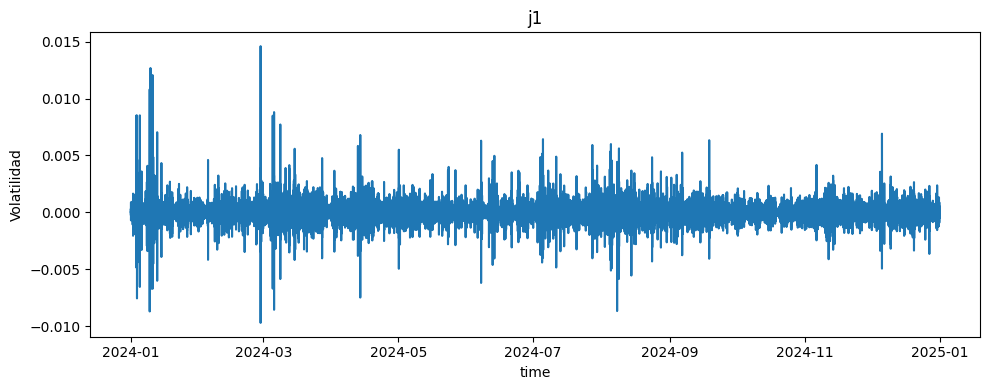

In [ ]:
s = df10["j1"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df10.loc[s.index, "time"], s.values)
plt.title("j1")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

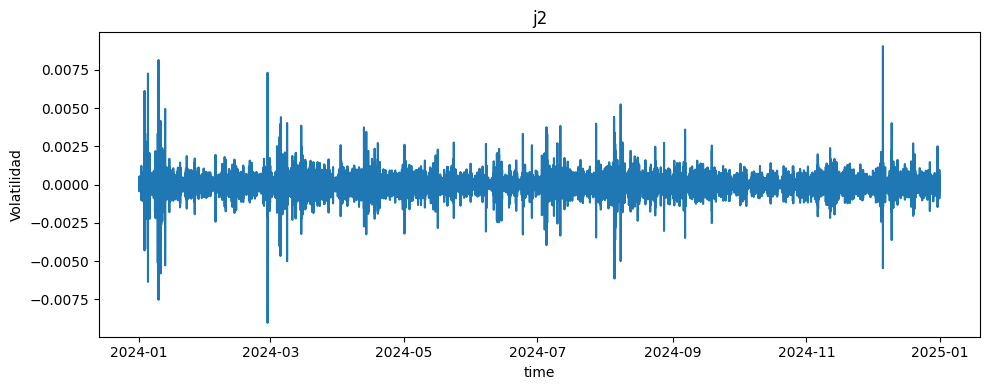

In [ ]:
s = df10["j2"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df10.loc[s.index, "time"], s.values)
plt.title("j2")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

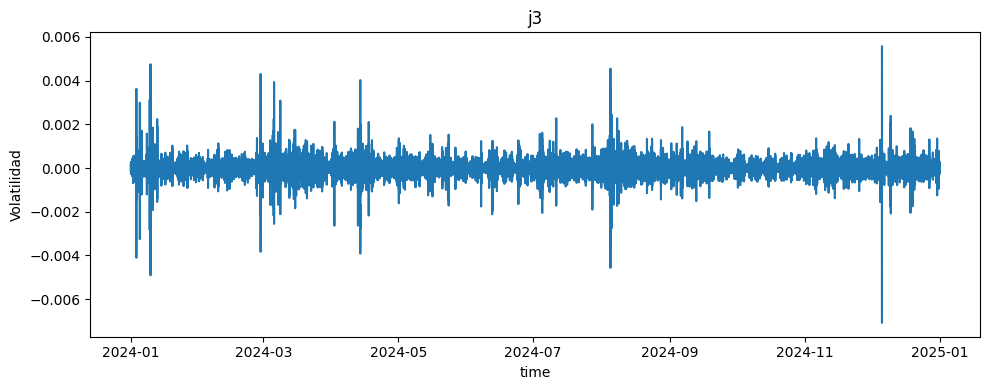

In [ ]:
s = df10["j3"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df10.loc[s.index, "time"], s.values)
plt.title("j3")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

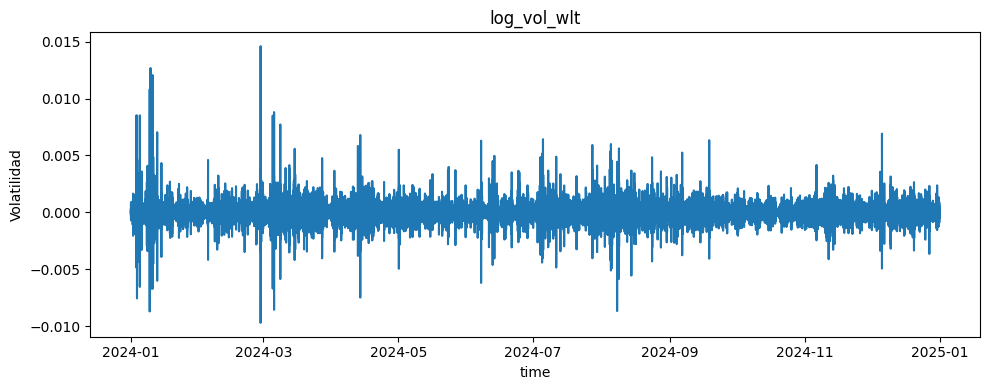

In [ ]:
s = df10["j1"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df10.loc[s.index, "time"], s.values)
plt.title("j1")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

In [ ]:
# Aplicamos modwlt sobre las js individualmente para su posterior agregacion y suavizado,
# asi como su uso en sujeto individual

In [ ]:
#                                                                                   Fin Acceso directo

##### J1

In [ ]:
#Js crudos

In [ ]:
df10["RV_2"] = df10["RV_r"]**2

Energia local suavizada

In [ ]:
import numpy as np
import pandas as pd
import pywt
from scipy.signal import lfilter

def get_modwt_final_boss(df, col, w_name="db4", J=3):
    """
    MODWT Causal con Normalización de Percival & Walden,
    Notación Científica y Validación de Energía Ortogonal.
    """
    # 1. Preparación de datos
    x = df[col].fillna(0.0).values
    n = len(x)

    wavelet = pywt.Wavelet(w_name)
    h_base = wavelet.dec_hi / np.sqrt(2)
    g_base = wavelet.dec_lo / np.sqrt(2)
    L = len(h_base)

    current_a = x
    res_cols = []

    # 2. Descomposición Multinivel Causal
    for j in range(1, J + 1):
        step = 2**(j-1)
        # Dilatación del filtro (Algoritmo à trous)
        h_dil = np.zeros(L + (L - 1) * (step - 1))
        g_dil = np.zeros(L + (L - 1) * (step - 1))
        h_dil[::step] = h_base
        g_dil[::step] = g_base

        # Filtrado LFilter (Causalidad garantizada por Scipy)
        wj = lfilter(h_dil, [1.0], current_a)
        vj = lfilter(g_dil, [1.0], current_a)

        df[f"j1_j{j}"] = wj
        res_cols.append(f"j1_j{j}")
        current_a = vj

    df[f"a1_a{J}"] = current_a
    res_cols.append(f"a1_a{J}")



    # 3. Embargo y Auditoría Científica
    max_warmup = (L - 1) * (2**J - 1)

    # Limpiamos bordes para el test
    clean_df = df.iloc[max_warmup:].copy().dropna()

    if len(clean_df) > 100:
        # Usamos el mismo segmento para X y para los Coeficientes
        x_clean = x[max_warmup:max_warmup + len(clean_df)]

        var_x = np.var(x_clean, ddof=1)
        var_coeffs = clean_df[res_cols].var(ddof=1).sum()

        # Imprimir con precisión científica para evitar el "redondeo a cero"
        print("🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):")
        print(f"   Varianza Original (Var(x)): {var_x:.8e}")
        print(f"   Suma Varianzas (ΣVar):      {var_coeffs:.8e}")

        error_rel = np.abs(var_x - var_coeffs) / var_x if var_x > 0 else 0
        print(f"   Error Relativo:             {error_rel:.4%}")

        # Test de correlación (para demostrar que los niveles capturan info distinta)
        avg_corr = clean_df[res_cols].corr().abs().values[np.triu_indices(len(res_cols), k=1)].mean()
        print(f"   Correlación Media Inter-Nivel: {avg_corr:.4f}")

    # Aplicar NaNs de seguridad en el DataFrame original
    for col_res in res_cols:
        df.loc[df.index[:max_warmup], col_res] = np.nan

    return df

# Ejecución
df10 = get_modwt_final_boss(df10, "j1", w_name="db4", J=2)

🔬 AUDITORÍA DE ENERGÍA (NOTACIÓN CIENTÍFICA):
   Varianza Original (Var(x)): 3.97861958e-08
   Suma Varianzas (ΣVar):      3.97862380e-08
   Error Relativo:             0.0001%
   Correlación Media Inter-Nivel: 0.1359


In [ ]:
df10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3162240 entries, 0 to 31622390
Data columns (total 14 columns):
 #   Column    Dtype         
---  ------    -----         
 0   time      datetime64[ns]
 1   day       int64         
 2   close     float64       
 3   close_ln  float64       
 4   r         float64       
 5   RV_r      float64       
 6   j1        float64       
 7   j2        float64       
 8   j3        float64       
 9   a3        float64       
 10  RV_2      float64       
 11  j1_j1     float64       
 12  j1_j2     float64       
 13  a1_a2     float64       
dtypes: datetime64[ns](1), float64(12), int64(1)
memory usage: 337.8 MB


In [ ]:
import numpy as np
import pandas as pd

def audit_v2_structure(df, detail_cols, approx_col, original_col):
    # 1. Preparación de datos (usando el segmento 'limpio' sin NaNs del warmup)
    # Calculamos el warmup basado en db4 y J=2 (aprox 21-25 filas)
    warmup = 30
    clean_df = df.iloc[warmup:].dropna(subset=[original_col] + detail_cols + [approx_col])

    # Referencia original
    x = clean_df[original_col].values
    total_energy = np.sum(x**2)

    # 2. Energía por Nivel y Ratio
    # Incluimos los detalles y la aproximación final para la identidad de Parseval
    all_coeffs = detail_cols + [approx_col]
    energy_by_level = np.array([np.sum(clean_df[c]**2) for c in all_coeffs])
    wave_energy = energy_by_level.sum()
    energy_ratio = wave_energy / total_energy if total_energy > 0 else np.nan
    energy_shares = energy_by_level / wave_energy if wave_energy > 0 else energy_by_level

    # 3. Entropía de Shannon (Distribución de la energía entre escalas)
    # Una entropía alta = la aceleración de la vol es multiescala.
    p = energy_shares[energy_shares > 0]
    entropy = -np.sum(p * np.log(p))

    # 4. Análisis de Autocorrelación (ACF) y Q sobre el nivel más fino (j1_j1)
    def get_acf_stats(series, max_lag=20):
        v = series.values
        v = v - np.mean(v)
        n = len(v)
        denom = np.dot(v, v)
        if denom == 0: return 0, 0, 0

        acfs = [np.dot(v[:-l], v[l:]) / denom for l in range(1, max_lag + 1)]
        acfs = np.array(acfs)

        max_acf = np.max(np.abs(acfs))
        mean_acf = np.mean(np.abs(acfs))
        # Q-stat (Portmanteau simplificado)
        q_stat = n * np.sum(acfs**2)
        return max_acf, mean_acf, q_stat

    max_acf, mean_acf, q_stat = get_acf_stats(clean_df[detail_cols[0]])

    # 5. Output con Estilo
    print(f"📊 ESTADÍSTICOS MODWT (V2 sobre {original_col}):")
    print(f"---")
    print(f"✅ Energy Ratio: {energy_ratio:.6f} (Cercano a 1 = Sin pérdida)")
    print(f"✅ Energy Shares: {list(np.round(energy_shares, 4))} (Niveles: {all_coeffs})")
    print(f"✅ Shannon Entropy: {entropy:.4f}")
    print(f"✅ Q-Stat (j1_j1): {q_stat:.2f}")
    print(f"✅ Max ACF (j1_j1): {max_acf:.4f}")
    print(f"✅ Mean ACF (j1_j1): {mean_acf:.4f}")

# Uso:
audit_v2_structure(df10, ["j1_j1", "j1_j2"], "a1_a2", "j1")

📊 ESTADÍSTICOS MODWT (V2 sobre j1):
---
✅ Energy Ratio: 1.000000 (Cercano a 1 = Sin pérdida)
✅ Energy Shares: [np.float64(0.8663), np.float64(0.1299), np.float64(0.0038)] (Niveles: ['j1_j1', 'j1_j2', 'a1_a2'])
✅ Shannon Entropy: 0.4106
✅ Q-Stat (j1_j1): 1574932.72
✅ Max ACF (j1_j1): 0.6776
✅ Mean ACF (j1_j1): 0.0544


In [ ]:
for j in range(1, 4):
    c = df10[f"j{j}"]
    df10[f"js{j}"] = (c*c).rolling(3, min_periods=1).mean()

In [ ]:
df10["es"] = df10["js1"]
df10["em"] = df10["js2"]
df10["el"] = df10["js3"]

In [ ]:
df10["e_d"] = df10["es"] + df10["em"] + df10["el"]
s = df10["e_d"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())

Ceros: 0
Nulls: 49


In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_d"])
df10["erm"] = np.log((df10["em"]) / df10["e_d"])
df10["erl"] = np.log((df10["el"]) / df10["e_d"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["vol_wlt"] = np.sqrt(df10["e_d"])

In [ ]:
s = df10["vol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 49


In [ ]:
df10["log_vol_wlt"] = np.log(df10["vol_wlt"])

In [ ]:
df10["as3"] = (df10["a3"] * df10["a3"]).rolling(3, min_periods=1).mean()
df10["e_total"] = df10["es"] + df10["em"] + df10["el"] + df10["as3"]

In [ ]:
df10["ers"] = np.log((df10["es"]) / df10["e_total"])
df10["erm"] = np.log((df10["em"]) / df10["e_total"])
df10["erl"] = np.log((df10["el"]) / df10["e_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["tvol_wlt"] = np.sqrt(df10["e_total"])

In [ ]:
s = df10["tvol_wlt"]
print("Ceros:", (s == 0).sum())
print("Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

Ceros: 0
Nulls: 49


In [ ]:
df10["tlog_vol_wlt"] = np.log(df10["tvol_wlt"])

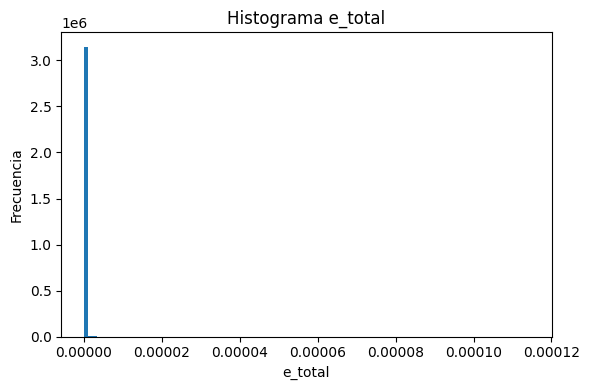

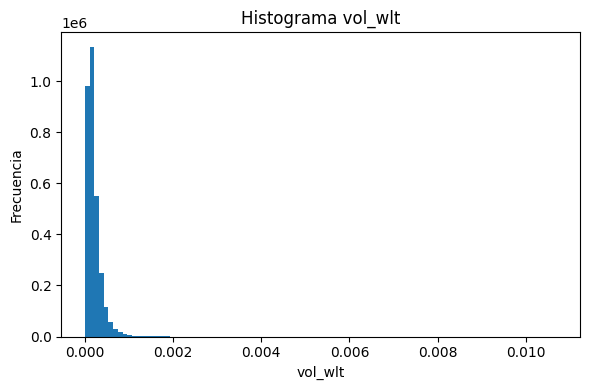

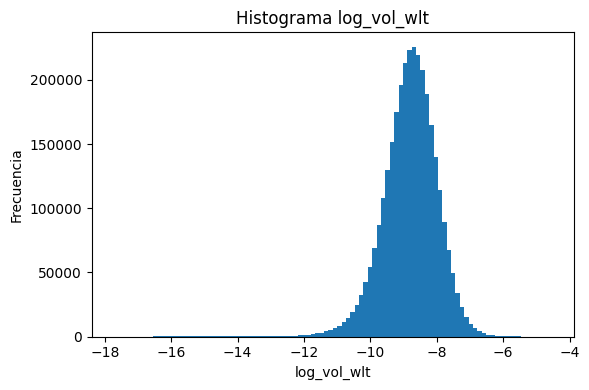

In [ ]:
import matplotlib.pyplot as plt

#CLEANS
# Histograma e_total
plt.figure(figsize=(6,4))
plt.hist(df10["e_d"].dropna(), bins=100)
plt.title("Histograma e_total")
plt.xlabel("e_total"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["vol_wlt"].dropna(), bins=100)
plt.title("Histograma vol_wlt")
plt.xlabel("vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

# Histograma log_vol_wlt
plt.figure(figsize=(6,4))
plt.hist(df10["log_vol_wlt"].dropna(), bins=100)
plt.title("Histograma log_vol_wlt")
plt.xlabel("log_vol_wlt"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-08-22 20:38:40
Fin   : 2024-08-22 20:43:40


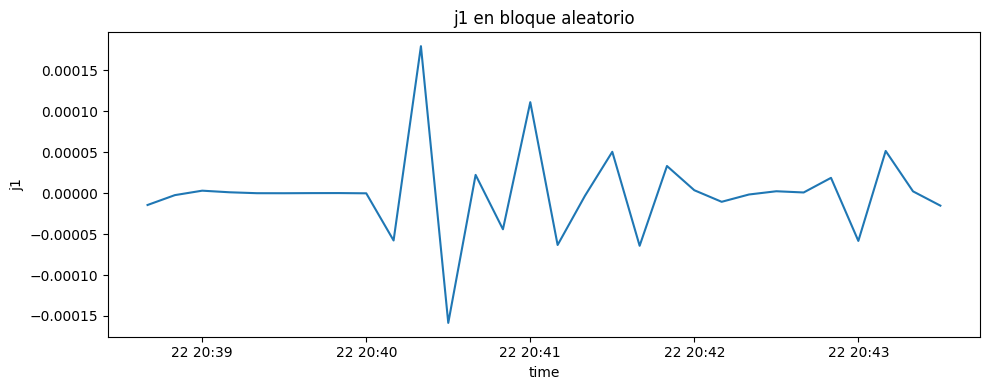

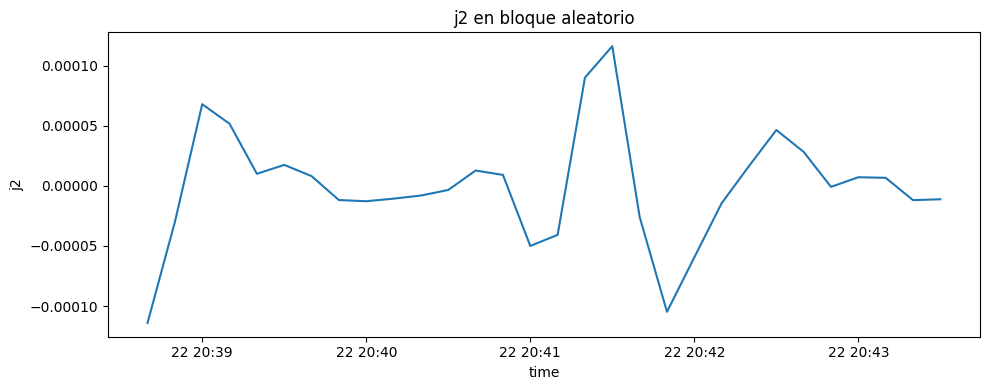

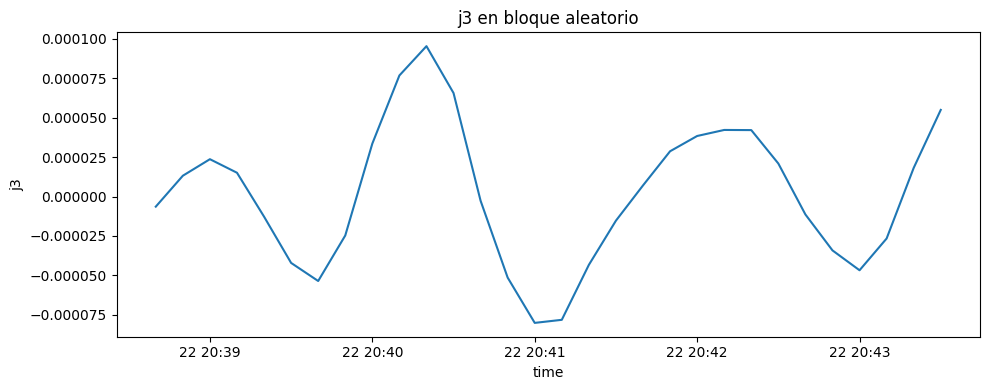

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_j = [f"j{i}" for i in range(1, 4)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_j].dropna()

# 3) Graficar j1 a j6
for j in cols_j:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[j])
    plt.title(f"{j} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(j)
    plt.tight_layout(); plt.show()

Bloque elegido:
Inicio: 2024-11-19 13:01:46
Fin   : 2024-11-19 13:06:46


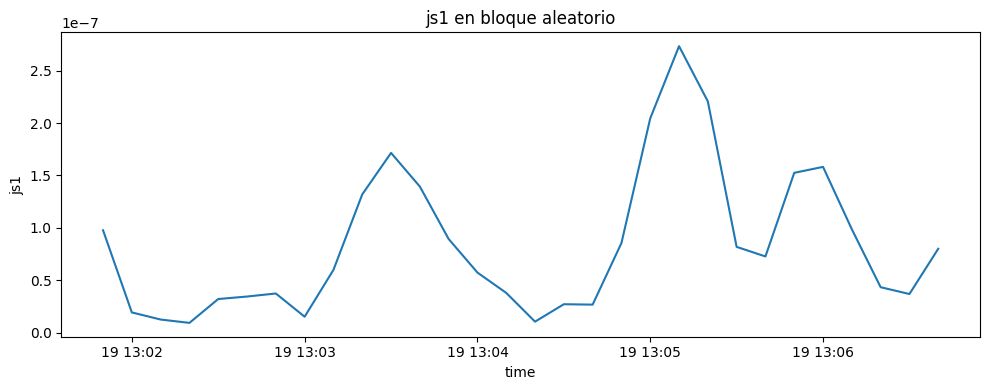

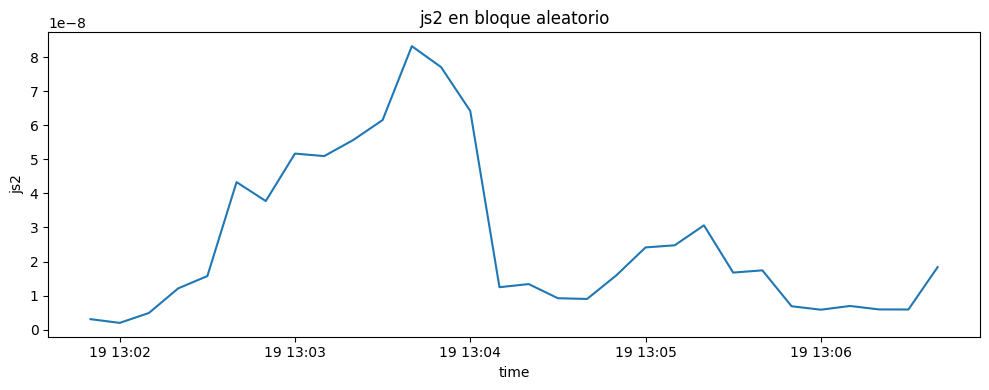

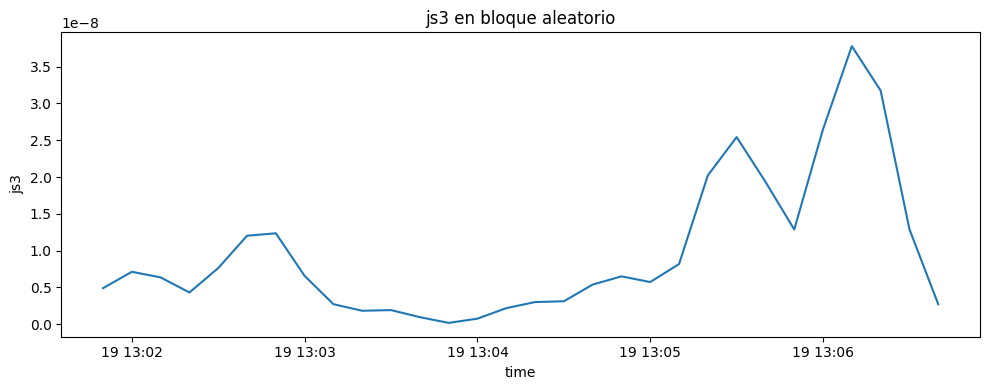

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Aseguramos que 'time' sea datetime
df10["time"] = pd.to_datetime(df10["time"])

# 1) Definir rango posible para elegir un bloque continuo
t_min = df10["time"].min()
t_max = df10["time"].max() - pd.Timedelta(hours=8)

offset_segundos = np.random.randint(0, int((t_max - t_min).total_seconds()) + 1)
t_inicio = t_min + pd.Timedelta(seconds=offset_segundos)
t_fin = t_inicio + pd.Timedelta(minutes=5)

print("Bloque elegido:")
print("Inicio:", t_inicio)
print("Fin   :", t_fin)

# 2) Filtrar bloque
cols_js = [f"js{i}" for i in range(1, 4)]
mask = (df10["time"] >= t_inicio) & (df10["time"] < t_fin)
sub = df10.loc[mask, ["time"] + cols_js].dropna()

# 3) Graficar js1 a js6
for js in cols_js:
    plt.figure(figsize=(10, 4))
    plt.plot(sub["time"], sub[js])
    plt.title(f"{js} en bloque aleatorio")
    plt.xlabel("time"); plt.ylabel(js)
    plt.tight_layout(); plt.show()

*Eshort, Emedium and ELong all RAW*

In [ ]:
df10["des"] = df10["j1"]
df10["dem"] = df10["j2"]
df10["del"] = df10["j3"]

In [ ]:
s = df10["des"]
print("des Ceros:", (s == 0).sum())
print("des Nulls:", s.isna().sum())
s = df10["dem"]
print("dem Ceros:", (s == 0).sum())
print("dem Nulls:", s.isna().sum())
s = df10["del"]
print("del Ceros:", (s == 0).sum())
print("del Nulls:", s.isna().sum())
# muchos 0 immplica epsilon mas grande en vol_wlt apx 1e-8

des Ceros: 878
des Nulls: 49
dem Ceros: 0
dem Nulls: 49
del Ceros: 0
del Nulls: 49


In [ ]:
df10["de_total"] = df10["des"] + df10["dem"] + df10["del"]

In [ ]:
df10["dvol_wlt"] = np.sqrt(df10["de_total"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df10["dlog_vol_wlt"] = np.log(df10["dvol_wlt"])

***Signature Plot***

/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


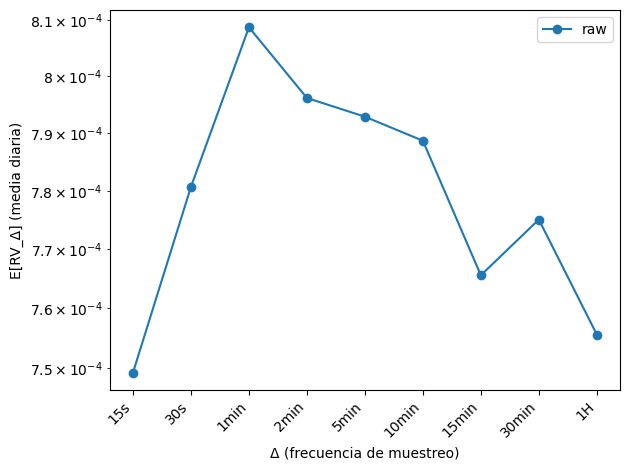

In [ ]:
  #signature plot estandar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def signature_rv_15s(
    df,
    t="time",
    logp="close_ln",
    deltas=("15s","30s","1min","2min","5min","10min","15min","30min","1H")
):
    x = df[[t, logp]].dropna().copy()
    x = x.sort_values(t).set_index(t)

    out = []
    for d in deltas:
        lp = x[logp].resample(d).last().dropna()
        r  = lp.diff().dropna()

        rv_block = r.pow(2).groupby(r.index.floor("D")).sum()
        out.append((d, rv_block.mean(), rv_block.median(), rv_block.size))

    return pd.DataFrame(out, columns=["delta","RV_mean","RV_median","n_days"])


sig_raw = signature_rv_15s(df10)

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ] (media diaria)")
ax.set_xlabel("Δ (frecuencia de muestreo)")
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()
/tmp/ipython-input-4038532487.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lp = x[logp].resample(d).last().dropna()


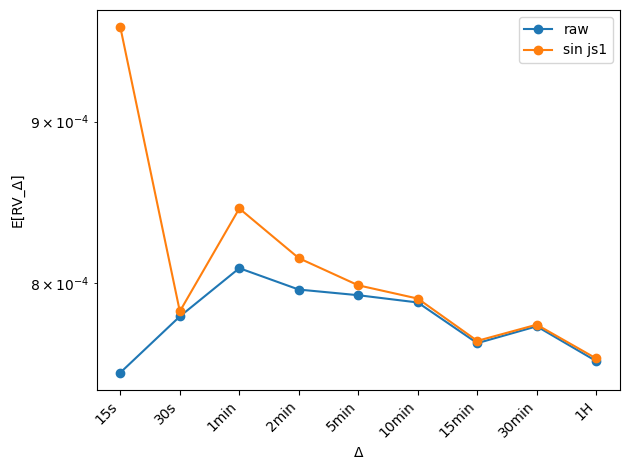

In [ ]:
def add_clean_logprice_15s(
    df,
    t="time",
    logp="close_ln",
    r="r",
    j1="j1",
    out="close_ln_clean"
):
    x = df[[t, logp, r, j1]].dropna().copy()
    x = x.sort_values(t)

    r_clean = (x[r] - x[j1]).to_numpy()
    x[out] = x[logp].iloc[0] + np.cumsum(r_clean)

    return x


df15_clean = add_clean_logprice_15s(df10)

sig_raw   = signature_rv_15s(df15_clean, logp="close_ln")
sig_clean = signature_rv_15s(df15_clean, logp="close_ln_clean")

fig, ax = plt.subplots()
ax.plot(sig_raw["RV_mean"].to_numpy(), marker="o", label="raw")
ax.plot(sig_clean["RV_mean"].to_numpy(), marker="o", label="sin js1")
ax.set_xticks(np.arange(len(sig_raw)))
ax.set_xticklabels(sig_raw["delta"].tolist(), rotation=45, ha="right")
ax.set_yscale("log")
ax.set_ylabel("E[RV_Δ]")
ax.set_xlabel("Δ")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def explosion_score(sig, k=5):
    y = np.log(sig["RV_mean"].to_numpy())
    x = np.log(np.arange(1, len(y) + 1))
    return (y[k] - y[0]) / (x[k] - x[0])

score_raw   = explosion_score(sig_raw)
score_clean = explosion_score(sig_clean)

score_raw, score_clean

(np.float64(0.02858545655243811), np.float64(-0.11057700345805258))

######SHAP

**1 min**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1 min = 6 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 6 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 6 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=6, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=6, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 7 | Test[527037:1054067]
   Fold 2: Train[49:1054061] | Gap: 7 | Test[1054068:1581098]
   Fold 3: Train[49:1581092] | Gap: 7 | Test[1581099:2108129]
   Fold 4: Train[49:2108123] | Gap: 7 | Test[2108130:2635160]
   Fold 5: Train[49:2635154] | Gap: 7 | Test[2635161:3162191]


In [ ]:
horizon = 6
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.602833  0.217362  0.466221  0.361399  0.610131  527022
1     2  0.646733  0.308256  0.555208  0.409706  0.657711  527022
2     3  0.611405  0.213361  0.461910  0.357258  0.612767  527022
3     4  0.637971  0.244146  0.494112  0.374735  0.640682  527022
4     5  0.594061  0.200768  0.448072  0.348750  0.596056  527022

PROMEDIO:
R2      0.618601
MSE     0.236779
RMSE    0.485105
MAE     0.370369
EVS     0.623469
dtype: float64


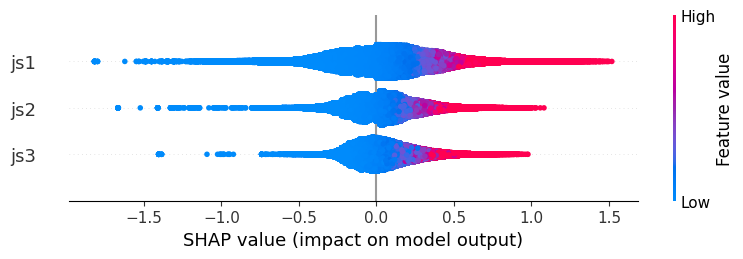

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**1 min navie**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.583386  0.228005  0.477499  0.370602  0.593654  527022
1     2  0.599950  0.349078  0.590829  0.422588  0.613252  527022
2     3  0.595198  0.222260  0.471444  0.364839  0.597902  527022
3     4  0.613553  0.260614  0.510504  0.385150  0.616262  527022
4     5  0.576158  0.209622  0.457845  0.356546  0.580161  527022

PROMEDIO:
R2      0.593649
MSE     0.253916
RMSE    0.501624
MAE     0.379945
EVS     0.600246
dtype: float64


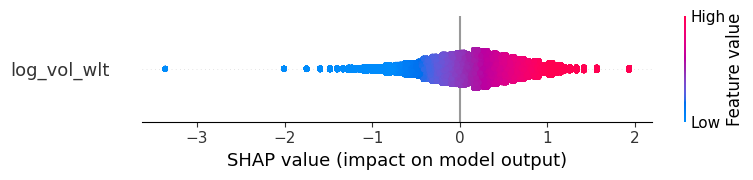

In [ ]:

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE

 #NAVIE                            #NAVIE                              #NAVIE

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#

import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd


class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["log_vol_wlt"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)




```
# Esto tiene formato de código
```

**1 min navie +shifted(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.562103  0.239653  0.489543  0.380756  0.573569  527022
1     2  0.577736  0.368462  0.607011  0.435805  0.592650  527022
2     3  0.575461  0.233098  0.482802  0.374393  0.578514  527022
3     4  0.592881  0.274554  0.523979  0.396610  0.595916  527022
4     5  0.555691  0.219745  0.468770  0.365652  0.560182  527022

PROMEDIO:
R2      0.572774
MSE     0.267102
RMSE    0.514421
MAE     0.390643
EVS     0.580166
dtype: float64


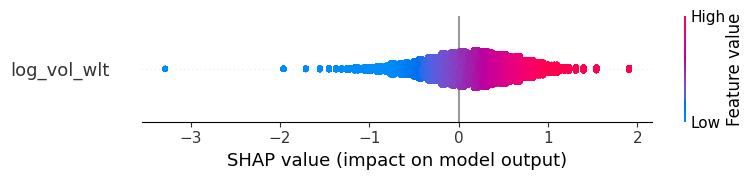

In [ ]:

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE

 #NAVIE                            #NAVIE                              #NAVIE

#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#NAVIE#

import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd


class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["log_vol_wlt"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49
# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

**1 min + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.579566  0.230095  0.479683  0.372951  0.588125  527022
1     2  0.621642  0.330150  0.574586  0.424404  0.634267  527022
2     3  0.589996  0.225117  0.474465  0.367993  0.591617  527022
3     4  0.615366  0.259390  0.509304  0.387249  0.618405  527022
4     5  0.571681  0.211837  0.460258  0.359030  0.574026  527022

PROMEDIO:
R2      0.595650
MSE     0.251318
RMSE    0.499659
MAE     0.382325
EVS     0.601288
dtype: float64


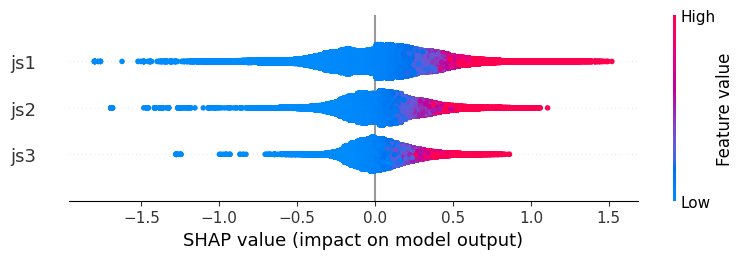

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49  # 6*10s = 1 min

# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**HF**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1/6 min = 1 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 1 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 1 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=1, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 1/6 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=1, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 2 | Test[527032:1054062]
   Fold 2: Train[49:1054061] | Gap: 2 | Test[1054063:1581093]
   Fold 3: Train[49:1581092] | Gap: 2 | Test[1581094:2108124]
   Fold 4: Train[49:2108123] | Gap: 2 | Test[2108125:2635155]
   Fold 5: Train[49:2635154] | Gap: 2 | Test[2635156:3162186]


In [ ]:
horizon = 1
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.814572  0.101481  0.318560  0.246697  0.815218  527023
1     2  0.851441  0.129633  0.360046  0.267857  0.853034  527023
2     3  0.814612  0.101786  0.319038  0.246578  0.814680  527023
3     4  0.836026  0.110584  0.332541  0.254370  0.836510  527023
4     5  0.802099  0.097876  0.312852  0.242405  0.802151  527023

PROMEDIO:
R2      0.823750
MSE     0.108272
RMSE    0.328608
MAE     0.251581
EVS     0.824319
dtype: float64


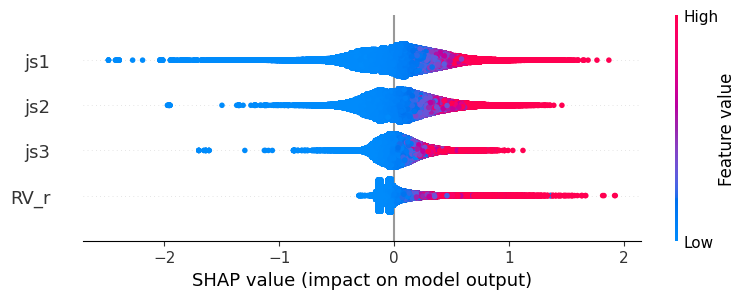

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3","RV_r"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.773240  0.124101  0.352279  0.269738  0.774945  527023
1     2  0.809565  0.166174  0.407644  0.298799  0.812447  527023
2     3  0.774529  0.123793  0.351842  0.269233  0.774775  527023
3     4  0.796733  0.137083  0.370247  0.279619  0.797528  527023
4     5  0.761888  0.117763  0.343167  0.263805  0.762283  527023

PROMEDIO:
R2      0.783191
MSE     0.133783
RMSE    0.365036
MAE     0.276239
EVS     0.784396
dtype: float64


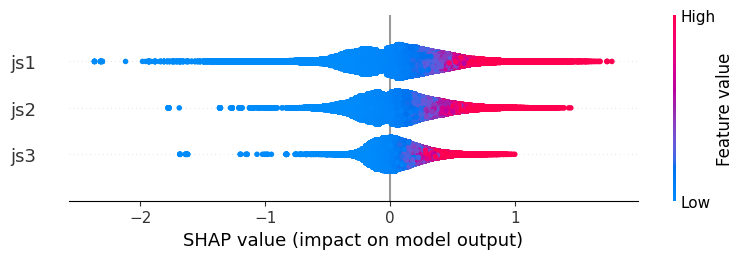

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)

**10 segs + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.672049  0.179480  0.423651  0.328483  0.676240  527023
1     2  0.724269  0.240603  0.490513  0.365421  0.730650  527023
2     3  0.675613  0.178102  0.422021  0.326740  0.676291  527023
3     4  0.705841  0.198380  0.445399  0.340075  0.707680  527023
4     5  0.658663  0.168816  0.410873  0.319779  0.659730  527023

PROMEDIO:
R2      0.687287
MSE     0.193076
RMSE    0.438491
MAE     0.336100
EVS     0.690118
dtype: float64


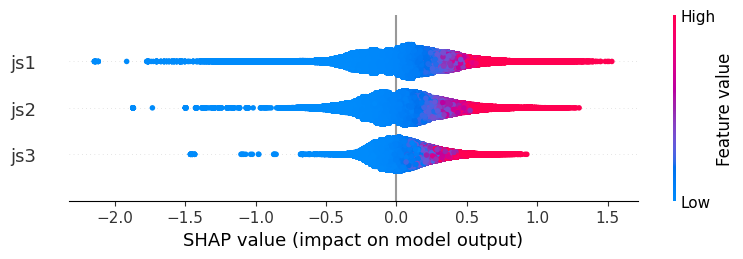

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 1, 49  # 6*10s = 1 min

# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**2 min**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 2 min = 12 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 12 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 12 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=12, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=12, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 13 | Test[527043:1054073]
   Fold 2: Train[49:1054061] | Gap: 13 | Test[1054074:1581104]
   Fold 3: Train[49:1581092] | Gap: 13 | Test[1581105:2108135]
   Fold 4: Train[49:2108123] | Gap: 13 | Test[2108136:2635166]
   Fold 5: Train[49:2635154] | Gap: 13 | Test[2635167:3162197]


In [ ]:
horizon = 12
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.485294  0.281690  0.530745  0.414707  0.499266  527021
1     2  0.499133  0.437042  0.661091  0.480747  0.520387  527021
2     3  0.500285  0.274400  0.523832  0.407174  0.503656  527021
3     4  0.511704  0.329283  0.573832  0.434338  0.516438  527021
4     5  0.483764  0.255319  0.505291  0.395159  0.488626  527021

PROMEDIO:
R2      0.496036
MSE     0.315547
RMSE    0.558958
MAE     0.426425
EVS     0.505675
dtype: float64


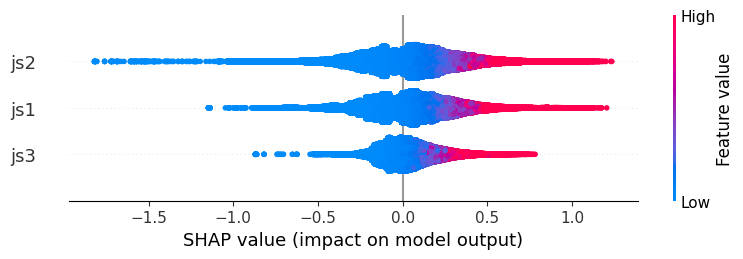

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 12, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


**5 min**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 5 min = 30 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_15min = 30 # muestras

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_15min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 30 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=30, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 5 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=30, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 31 | Test[527061:1054091]
   Fold 2: Train[49:1054061] | Gap: 31 | Test[1054092:1581122]
   Fold 3: Train[49:1581092] | Gap: 31 | Test[1581123:2108153]
   Fold 4: Train[49:2108123] | Gap: 31 | Test[2108154:2635184]
   Fold 5: Train[49:2635154] | Gap: 31 | Test[2635185:3162215]


In [ ]:
horizon = 30
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.419182  0.317875  0.563804  0.440681  0.437899  527018
1     2  0.360311  0.558145  0.747091  0.522204  0.398144  527018
2     3  0.430153  0.312997  0.559461  0.433516  0.434810  527018
3     4  0.419479  0.391417  0.625633  0.464399  0.427726  527018
4     5  0.427119  0.283336  0.532293  0.415484  0.432294  527018

PROMEDIO:
R2      0.411249
MSE     0.372754
RMSE    0.605657
MAE     0.455257
EVS     0.426175
dtype: float64


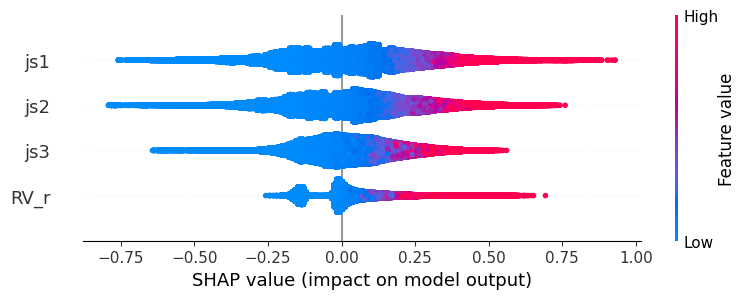

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3","RV_r"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 30, 49

# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


In [ ]:
# TOP HORIZONTES
# 1 MINUTO *
# 2 MINUTOS

###### SHAP REGIMENES

**1 minuto**

In [ ]:
def get_purge_embargo_indices(n_samples, train_idx, test_idx, horizon_secs, warmup_samples):
    """
    Calcula los índices a eliminar para evitar Leakage en la evaluación.
    Purge: Elimina datos donde el target del pasado toca el futuro.
    Embargo: Elimina datos donde las features (wavelet warmup) tocan el pasado.
    """
    # Horizon en muestras (ej: 1 min = 6 muestras de 10s)
    horizon_samples = int(horizon_secs / 10)

    # 1. Purge: El test no puede empezar inmediatamente después del train
    # porque el target en el final del train 'mira' hacia el inicio del test.
    purged_train_end = train_idx[-1] - horizon_samples

    # 2. Embargo: El train no puede empezar inmediatamente después del test
    # porque las features wavelets al inicio del train usaron datos del test.
    embargo_size = int(warmup_samples * 1.1) # 10% de margen extra
    embargoed_train_start = test_idx[-1] + embargo_size

    return purged_train_end, embargoed_train_start

# Parámetros para tu caso:
J = 3
L = 8 # Para db4
max_warmup = (L - 1) * (2**J - 1) # 49 muestras (8.1 minutos a 10s)
horizon_min = 6

print(f"🛡️ Blindaje Institucional:")
print(f"   Debes purgar {horizon_min} muestras antes de cada set de test.")
print(f"   Debes aplicar embargo de {max_warmup} muestras después de cada set de test.")

🛡️ Blindaje Institucional:
   Debes purgar 6 muestras antes de cada set de test.
   Debes aplicar embargo de 49 muestras después de cada set de test.


In [ ]:
class CausalTimeSplitter:
    def __init__(self, horizon_samples, warmup_samples, n_splits=5):
        self.horizon = horizon_samples
        self.warmup = warmup_samples
        self.n_splits = n_splits

    def split(self, data):
        n = len(data)
        # Calculamos el tamaño de cada bloque de test
        test_size = n // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # Fin del entrenamiento y inicio del test
            train_end = i * test_size
            test_start = train_end + self.horizon # Purge aplicado
            test_end = test_start + test_size

            if test_end > n:
                break

            # El set de entrenamiento real debe terminar antes del horizonte
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            yield train_indices, test_indices

# Uso práctico con tus datos
splitter = CausalTimeSplitter(horizon_samples=6, warmup_samples=49)

for train_idx, test_idx in splitter.split(df10):
    # Aquí entrenas tu modelo con df10.iloc[train_idx]
    # Y validas con df10.iloc[test_idx]
    pass

print("🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.")

🏁 Sistema Blindado: Filtro causal + Purge/Embargo CV.


In [ ]:
import numpy as np

class InstitutionalCausalSplitter:
    def __init__(self, df, horizon_samples, feature_warmup, n_splits=5):
        self.df = df
        self.n = len(df)
        self.horizon = horizon_samples
        self.warmup = feature_warmup # El lookback_max (49 para tu WLT)
        self.n_splits = n_splits

    def split(self):
        # Tamaño del bloque de test (dejando espacio para el último test)
        test_size = (self.n - self.warmup) // (self.n_splits + 1)

        for i in range(1, self.n_splits + 1):
            # 1. Punto de corte: fin del entrenamiento
            train_end = i * test_size

            # 2. PURGE: El test NO puede empezar cerca del final del train
            # El target del train_end mira 'horizon' hacia adelante.
            test_start = train_end + self.horizon
            test_end = test_start + test_size

            if test_end > self.n:
                break

            # 3. EMBARGO: El siguiente train (si fuera un CV circular)
            # no podría usar datos que el test 'tocó' con su lookback.
            # En Walk-Forward (que es lo que hacemos), el entrenamiento
            # siempre es previo al test, por lo que el embargo protege
            # que las features del test no usen info del train.

            # Índices finales:
            # Quitamos el warmup al inicio para que el modelo no vea NaNs/Basura
            train_indices = np.arange(self.warmup, train_end)
            test_indices = np.arange(test_start, test_end)

            # Verificación de integridad
            gap = test_indices[0] - train_indices[-1]
            if gap < self.horizon:
                raise ValueError("🚨 Leakage detectado: Gap menor al horizonte!")

            yield train_indices, test_indices

# Aplicación con tus datos exactos (Wavelet J=3 db4 + Target 2 min)
# Horizon = 30 (5 min / 10s)
# Warmup = 49 (Wavelet lookback)
splitter = InstitutionalCausalSplitter(df10, horizon_samples=6, feature_warmup=49)

print(f"🔬 Auditoría de Split:")
for j, (train, test) in enumerate(splitter.split()):
    print(f"   Fold {j+1}: Train[{train[0]}:{train[-1]}] | Gap: {test[0]-train[-1]} | Test[{test[0]}:{test[-1]}]")

🔬 Auditoría de Split:
   Fold 1: Train[49:527030] | Gap: 7 | Test[527037:1054067]
   Fold 2: Train[49:1054061] | Gap: 7 | Test[1054068:1581098]
   Fold 3: Train[49:1581092] | Gap: 7 | Test[1581099:2108129]
   Fold 4: Train[49:2108123] | Gap: 7 | Test[2108130:2635160]
   Fold 5: Train[49:2635154] | Gap: 7 | Test[2635161:3162191]


In [ ]:
horizon = 6
df10["log_vol_future"] = df10["log_vol_wlt"].shift(-horizon)

**1 min + Shift(1)**

   fold        R2       MSE      RMSE       MAE       EVS  n_test
0     1  0.549292  0.246664  0.496653  0.387814  0.559376  527022
1     2  0.588888  0.358730  0.598940  0.443133  0.603707  527022
2     3  0.561238  0.240909  0.490825  0.382031  0.563211  527022
3     4  0.585668  0.279417  0.528599  0.403324  0.589191  527022
4     5  0.542651  0.226195  0.475599  0.372230  0.545765  527022

PROMEDIO:
R2      0.565548
MSE     0.270383
RMSE    0.518123
MAE     0.397706
EVS     0.572250
dtype: float64


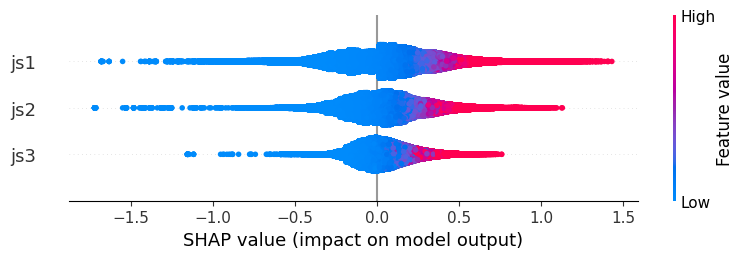

In [ ]:
import numpy as np, shap, xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
import pandas as pd

class InstitutionalCausalSplitter:
    def __init__(self, n, horizon, warmup, n_splits=5):
        self.n, self.horizon, self.warmup, self.n_splits = n, horizon, warmup, n_splits
    def split(self):
        test_size = (self.n - self.warmup)//(self.n_splits+1)
        for i in range(1, self.n_splits+1):
            train_end = i*test_size
            test_start = train_end + self.horizon
            test_end   = test_start + test_size
            if test_end > self.n: break
            tr = np.arange(self.warmup, train_end)
            te = np.arange(test_start, test_end)
            if te[0] - tr[-1] < self.horizon:
                raise ValueError("Leakage: gap < horizon")
            yield tr, te

# --- params (10s freq, 5min horizon) ---
features = ["js1","js2","js3"]
target   = "log_vol_future"
horizon_samples, warmup_samples = 6, 49  # 6*10s = 1 min

# shift causal de features
df10[features] = df10[features].shift(1)


# --- data ---
df = df10[features + [target]].dropna()
X, y = df[features], df[target]

splitter = InstitutionalCausalSplitter(len(df), horizon_samples, warmup_samples, n_splits=5)

rows = []
last_model = last_Xte = last_yte = None

for fold, (tr, te) in enumerate(splitter.split(), 1):
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    Xte, yte = X.iloc[te], y.iloc[te]

    m = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=2000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        early_stopping_rounds=50
    )

    m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)

    p = m.predict(Xte)
    mse = mean_squared_error(yte, p)

    rows.append({
        "fold": fold,
        "R2": r2_score(yte, p),
        "MSE": mse,
        "RMSE": mse**0.5,
        "MAE": mean_absolute_error(yte, p),
        "EVS": explained_variance_score(yte, p),
        "n_test": len(te)
    })

    last_model, last_Xte, last_yte = m, Xte, yte

# --- resumen métricas ---
res = pd.DataFrame(rows)
print(res)
print("\nPROMEDIO:")
print(res.drop(columns=["fold","n_test"]).mean())

# --- SHAP beeswarm (último fold OOS) ---
explainer = shap.TreeExplainer(last_model)
sv = explainer.shap_values(last_Xte)
shap.summary_plot(sv, last_Xte, plot_type="dot", show=True)


/tmp/ipython-input-3688304185.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  regime_metrics = analysis.groupby('Regime', observed=True).apply(lambda x: pd.Series({
/tmp/ipython-input-3688304185.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Regime', y='Error', data=analysis, palette='viridis')


📊 MÉTRICAS POR RÉGIMEN DE VOLATILIDAD:
                  R2       MAE      Bias     Count
Regime                                            
Baja        0.200900  0.428260  0.073286  105405.0
Media-Baja  0.000434  0.368066 -0.003067  105404.0
Media      -0.034229  0.353819 -0.044512  105404.0
Media-Alta -0.073792  0.351280 -0.085040  105404.0
Alta        0.039384  0.359724 -0.136883  105405.0


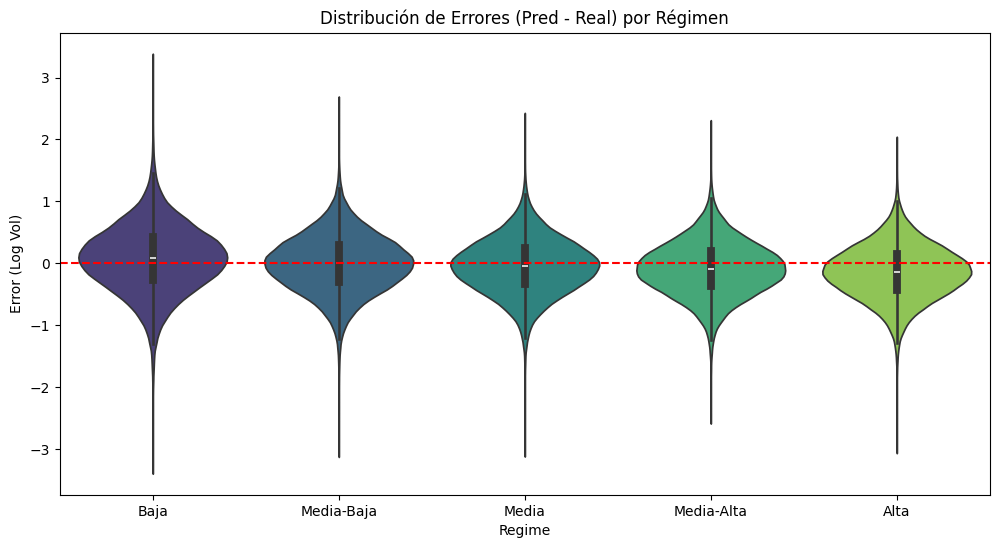

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperamos la volatilidad actual para el último fold de test
# Asumimos que 'log_vol_now' está alineada con 'last_Xte'
vol_now_test = df10.loc[last_Xte.index, "log_vol_wlt"]

# 2. Creamos los 5 regímenes basados en quintiles
regime_labels = ['Baja', 'Media-Baja', 'Media', 'Media-Alta', 'Alta']
regimes = pd.qcut(vol_now_test, 5, labels=regime_labels)

# 3. Construimos el DataFrame de análisis de residuos
analysis = pd.DataFrame({
    'Real': last_yte,
    'Pred': last_model.predict(last_Xte),
    'Regime': regimes
})
analysis['Error'] = analysis['Pred'] - analysis['Real']
analysis['AbsError'] = analysis['Error'].abs()

# 4. Cálculo de métricas por régimen
regime_metrics = analysis.groupby('Regime', observed=True).apply(lambda x: pd.Series({
    'R2': r2_score(x['Real'], x['Pred']),
    'MAE': x['AbsError'].mean(),
    'Bias': x['Error'].mean(),
    'Count': len(x)
}))

print("📊 MÉTRICAS POR RÉGIMEN DE VOLATILIDAD:")
print(regime_metrics)

# 5. Visualización de la "Firma del Error"
plt.figure(figsize=(12, 6))
sns.violinplot(x='Regime', y='Error', data=analysis, palette='viridis')
plt.axhline(0, color='red', linestyle='--')
plt.title('Distribución de Errores (Pred - Real) por Régimen')
plt.ylabel('Error (Log Vol)')
plt.show()

In [ ]:
# el modelo es mas preciso en los extremos, el R2 no es importante por la microvarianza inherente al experimento
# Posibles complementos
# 1. modelo truncado
# 2. Wavelet mas larga Js


# complemento indispensable:
# rolling explosition score from signature plot, a 1 hora, 2 horas, o algo asi

######Blocks minutes

15 minutes

In [ ]:
import numpy as np
import pandas as pd

df10["time"] = pd.to_datetime(df10["time"])
df_ = df10.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("15T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-1741640544.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("15T").mean()
/tmp/ipython-input-1741640544.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.9223944872133529
Spearman: 0.9728770194837482
Kendall : 0.8642381953500718


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.9728770194837482
Kendall : 0.8642381953500718


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


5 minutes

In [ ]:
import numpy as np
import pandas as pd

df10["time"] = pd.to_datetime(df10["time"])
df_ = df10.set_index("time")

# 1) Mean por defecto
df15m = df_.resample("5T").mean()

# 2) Columnas aditivas (sum)
sum_cols = [
    "RV_r",
    "j1","j2","j3",
    "js1","js2","js3",
    "es","em","el","e_d",
    "ers","erm","erl",
    "e_total",
    "des","dem","del","de_total"
]

df15m[sum_cols] = df_[sum_cols].resample("5T").sum()
df15m = df15m.reset_index()

/tmp/ipython-input-1207572129.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m = df_.resample("5T").mean()
/tmp/ipython-input-1207572129.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df15m[sum_cols] = df_[sum_cols].resample("5T").sum()


In [ ]:
df15m["vol_wlt"]      = np.sqrt(df15m["e_d"])
df15m["log_vol_wlt"]  = np.log(df15m["vol_wlt"])

df15m["tvol_wlt"]     = np.sqrt(df15m["e_total"])
df15m["tlog_vol_wlt"] = np.log(df15m["tvol_wlt"])

df15m["dvol_wlt"]     = np.sqrt(df15m["de_total"])
df15m["dlog_vol_wlt"] = np.log(df15m["dvol_wlt"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "e_d"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["e_d"], method="pearson")
spearman = s["RV_r"].corr(s["e_d"], method="spearman")
kendall  = s["RV_r"].corr(s["e_d"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : 0.9133079979737936
Spearman: 0.969115585222217
Kendall : 0.8545449970438539


In [ ]:
# Limpieza mínima
s = df15m[["RV_r", "log_vol_wlt"]].dropna()

# Correlaciones
pearson  = s["RV_r"].corr(s["log_vol_wlt"], method="pearson")
spearman = s["RV_r"].corr(s["log_vol_wlt"], method="spearman")
kendall  = s["RV_r"].corr(s["log_vol_wlt"], method="kendall")

print("Pearson :", pearson)
print("Spearman:", spearman)
print("Kendall :", kendall)

Pearson : nan
Spearman: 0.969115585222217
Kendall : 0.8545449970438539


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


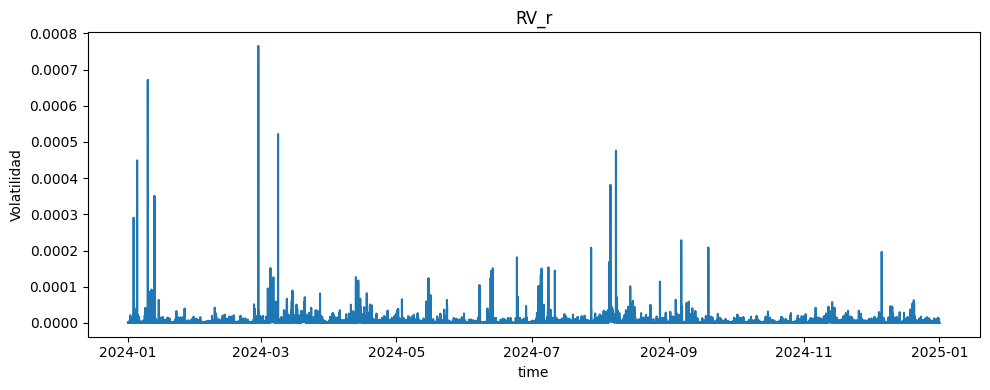

In [ ]:
s = df15m["RV_r"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("RV_r")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

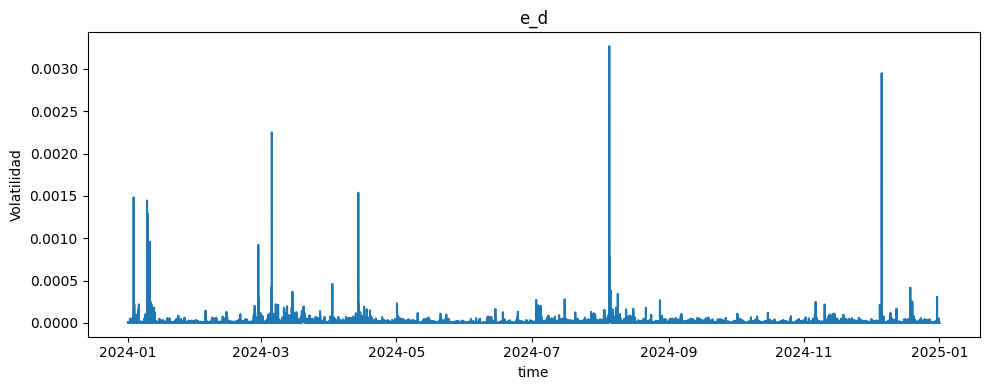

In [ ]:
s = df15m["e_d"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15m.loc[s.index, "time"], s.values)
plt.title("e_d")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

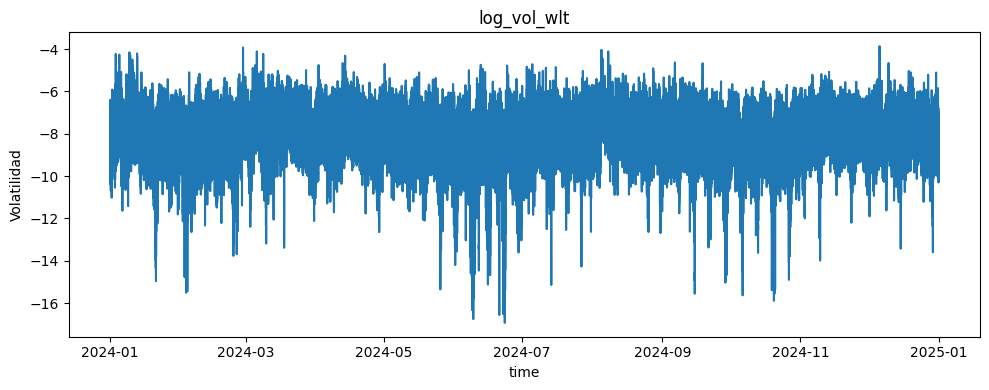

In [ ]:
s = df15["log_vol_wlt"].astype(float).dropna()

plt.figure(figsize=(10,4))
plt.plot(df15.loc[s.index, "time"], s.values)
plt.title("log_vol_wlt")
plt.xlabel("time"); plt.ylabel("Volatilidad")
plt.tight_layout(); plt.show()

***Test iniciales***

In [ ]:
import pandas as pd

x = df15m["vol_wlt"]
r = df15m["r"]

corr_t   = x.corr(r)
corr_tp1 = x.corr(r.shift(-1))

corr_t, corr_tp1

(np.float64(0.009346382080625977), np.float64(0.0037274259736032457))

In [ ]:
#no hay leakage

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lags = [5, 10, 20]

lb_js = {
    f"js{i}": acorr_ljungbox(df15m[f"js{i}"].dropna(), lags=lags, return_df=True)
    for i in [1, 2, 3]
}

lb_js

{'js1':          lb_stat  lb_pvalue
 5   54999.562312        0.0
 10  73851.169901        0.0
 20  92422.459761        0.0,
 'js2':          lb_stat  lb_pvalue
 5   49174.384471        0.0
 10  62040.193222        0.0
 20  74858.937948        0.0,
 'js3':          lb_stat  lb_pvalue
 5   35530.265008        0.0
 10  44092.392903        0.0
 20  51618.090716        0.0}

In [ ]:
#La volatilidad wavelet no es un artefacto de microestructura.
# POR LO TANTO; la vairable no es una varianza fisica sino es un estado latente de intensidad

In [ ]:
import numpy as np

targets = df15m["RV_r"]

corr_levels = {
    "js1": df15m["js1"].corr(targets),
    "js2": df15m["js2"].corr(targets),
    "js3": df15m["js3"].corr(targets),
}

corr_levels

{'js1': np.float64(0.4119542112895267),
 'js2': np.float64(0.4066213093031348),
 'js3': np.float64(0.4400764387086965)}

In [ ]:
#La señal es multiescala, no un truco de j1, por lo cual no es imprecindible

In [ ]:
vol_23 = np.sqrt(df15m["js2"]**2 + df15m["js3"]**2)
vol_23 = np.log(vol_23.replace(0, np.nan))

vol_23.corr(targets)

np.float64(0.2973378807779419)

In [ ]:
#Spearman alto es legítimo, no inflado artificialmente.

In [ ]:
# CONCLUSION
# Si la querés target en un GAT, hacelo ordinal (bins) y entrená para:

# alta Kendall/Spearman out-of-sample,

# estabilidad rolling,

# y consistencia de edges en ventanas.

# La versión “continua con MSE” es posible, pero es pelearte con la geometría equivocada: como medir temperatura con una regla.

# Si me decís cuántos activos y qué frecuencia (5m / 15m), te propongo la definición mínima de:

# nodos/features,

# edges (qué medida usar),

# y el head ordinal (K y thresholds) para que quede coherente con tu proxy.

# CVS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

Mounted at /content/drive


SAVE

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')

# Ruta donde querés guardar el archivo (podés cambiar el nombre o carpeta)
ruta_guardado = '/content/drive/MyDrive/VFJmf1.parquet'

# Guardar en formato Parquet, conservando la estructura y tipos
mf1.to_parquet(ruta_guardado, index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


APERTURA

In [ ]:
mf1 = pd.read_parquet('/content/drive/MyDrive/VFmf1.parquet')

KeyboardInterrupt: 

In [ ]:
mf1.info()